# Analisis Friksi Pasar, Penyerapan Permintaan, dan Simulasi Sasaran Inflasi Sulawesi Tenggara

Catatan kerja ini kita susun untuk naskah Kompetisi Opini Ilmiah Forkestra 2026. Semua pengolahan berangkat dari paket `dataset_final_sultra_forkestra2026.zip` yang sudah dibersihkan dan diperiksa mutunya, sehingga notebook ini berisi analisis, simulasi, dan penyusunan keluaran untuk naskah.

Urutan kerja kita:

1. Menyiapkan lingkungan kerja dan gaya visual.
2. Membuat folder keluaran dan fungsi bantu.
3. Memuat paket data dan memeriksa cakupannya.
4. Mengukur friksi pasar: selisih harga antarkota, perbedaan inflasi antarwilayah, posisi Sulawesi Tenggara di antara kota IHK nasional, dan sebaran harga produsen ikan.
5. Membaca penyerapan permintaan dan hilirisasi perikanan: produksi, ekspor, struktur permintaan akhir, kebutuhan ikan program MBG, dan nilai tukar nelayan.
6. Menguraikan inflasi dengan bobot IHK: bobot tersirat, andil kelompok, dan bobot komoditas pangan.
7. Menjalankan sistem simulasi: proyeksi dasar, inversi sasaran inflasi menjadi arahan harga, model sistem dinamis pasar ikan beserta dampaknya ke kemiskinan dan nilai tukar nelayan, pencarian kebijakan multitujuan, dan uji sensitivitas.
8. Menyimpan semua tabel, gambar, dan interpretasi, lalu memaketkannya menjadi satu berkas ZIP.

Tabel dan grafik memakai bahasa Inggris agar dapat langsung dipindahkan ke naskah. Penjelasan dan interpretasi otomatis memakai bahasa Indonesia, dan setiap kalimat interpretasi disusun dari angka hasil perhitungan pada sel yang sama.

## Langkah 1. Lingkungan kerja dan gaya visual

Kita memakai pandas, numpy, matplotlib, dan scipy; keempatnya sudah tersedia pada instalasi Anaconda. Huruf grafik diatur ke Times New Roman ukuran 13. Di Windows huruf ini biasanya sudah terpasang. Di Linux atau lingkungan server, salin berkas `times.ttf` (dan varian tebal atau miringnya) ke subfolder `fonts` di samping notebook agar terdaftar otomatis; bila tetap tidak ditemukan, dipakai Liberation Serif yang ukurannya setara.

In [1]:
import os, sys, re, glob, json, math, zipfile, shutil, textwrap, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
from scipy import optimize
from scipy.stats import norm

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 180)

# Daftarkan berkas huruf Times New Roman bila ada di folder 'fonts' atau di folder huruf sistem
for pola in ['fonts/*.ttf', 'fonts/*.TTF', 'C:/Windows/Fonts/times*.ttf', os.path.expanduser('~/Library/Fonts/Times*.ttf'),
             '/Library/Fonts/Times*.ttf', '/usr/share/fonts/**/[Tt]imes*.ttf', os.path.expanduser('~/.fonts/*.ttf')]:
    for berkas in glob.glob(pola, recursive=True):
        try:
            font_manager.fontManager.addfont(berkas)
        except Exception:
            pass
tersedia = {f.name for f in font_manager.fontManager.ttflist}
FONT_UTAMA = next((f for f in ['Times New Roman', 'Liberation Serif', 'Nimbus Roman', 'TeX Gyre Termes', 'DejaVu Serif'] if f in tersedia), 'DejaVu Serif')
plt.rcParams.update({
    'font.family': 'serif', 'font.serif': [FONT_UTAMA, 'Times New Roman', 'DejaVu Serif'], 'font.size': 13,
    'axes.titlesize': 13, 'axes.labelsize': 13, 'xtick.labelsize': 13, 'ytick.labelsize': 13, 'legend.fontsize': 13,
    'figure.titlesize': 13, 'mathtext.fontset': 'stix', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'figure.dpi': 100, 'savefig.dpi': 300})
RNG = np.random.default_rng(20260921)
print('Python', sys.version.split()[0], '| pandas', pd.__version__, '| numpy', np.__version__, '| matplotlib', matplotlib.__version__)
print('Huruf grafik:', FONT_UTAMA)

Python 3.13.15 | pandas 2.2.3 | numpy 2.1.3 | matplotlib 3.10.0
Huruf grafik: Liberation Serif


## Langkah 2. Folder keluaran dan fungsi bantu

Folder keluaran dibuat otomatis di folder kerja notebook dengan empat subfolder: `figures`, `tables`, `interpretations`, dan `simulation`. Bila notebook dijalankan di Google Colab dan `USE_GDRIVE = True`, folder dibuat di Google Drive. Fungsi bantu berikut menyimpan tabel, gambar, dan interpretasi secara seragam, serta menulis angka dengan format Indonesia (titik ribuan, koma desimal) di dalam teks interpretasi.

In [2]:
USE_GDRIVE = False
DI_COLAB = 'google.colab' in sys.modules
if USE_GDRIVE and DI_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/Forkestra2026'
else:
    BASE_DIR = os.getcwd()
os.makedirs(BASE_DIR, exist_ok=True)
OUT_DIR = os.path.join(BASE_DIR, 'output_forkestra2026')
SUB = {k: os.path.join(OUT_DIR, k) for k in ['figures', 'tables', 'interpretations', 'simulation']}
for p in SUB.values():
    os.makedirs(p, exist_ok=True)

TABEL, GAMBAR, TAFSIR = {}, {}, {}

def angka(x, d=2):
    """Format angka Indonesia untuk teks interpretasi."""
    try:
        x = float(x)
    except (TypeError, ValueError):
        return 'tidak tersedia'
    if not np.isfinite(x):
        return 'tidak tersedia'
    s = f'{x:,.{d}f}'
    return s.replace(',', '#').replace('.', ',').replace('#', '.')

def simpan_tabel(df, kode, judul):
    df.to_csv(os.path.join(SUB['tables'], f'{kode}.csv'), index=False, encoding='utf-8')
    TABEL[kode] = (judul, df.copy())
    return df

def simpan_gambar(fig, kode, judul):
    path = os.path.join(SUB['figures'], f'{kode}.png')
    fig.savefig(path, dpi=300, bbox_inches='tight')
    GAMBAR[kode] = (judul, path)
    plt.show()
    plt.close(fig)

def tafsir(kode, teks):
    teks = re.sub(r'\s+', ' ', teks).strip()
    TAFSIR.setdefault(kode, []).append(teks)
    print(textwrap.fill(teks, 115))
    print()

def geser(periode, k):
    return str(pd.Period(periode, freq='M') + k)

def ols(y, x):
    """Regresi linear sederhana dengan konstanta: koefisien, galat baku, R2, n."""
    y = np.asarray(y, float); x = np.asarray(x, float)
    X = np.column_stack([np.ones(len(x)), x])
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    res = y - X @ b
    n, k = X.shape
    s2 = (res @ res) / max(n - k, 1)
    se = np.sqrt(np.diag(s2 * np.linalg.inv(X.T @ X)))
    sst = ((y - y.mean()) ** 2).sum()
    r2 = 1 - (res @ res) / sst if sst > 0 else np.nan
    return b, se, r2, n

GROUP_EN = {'0': 'General', '01': 'Food, beverages and tobacco', '02': 'Clothing and footwear',
            '03': 'Housing, water, electricity and household fuels', '04': 'Furnishings, household equipment and maintenance',
            '05': 'Health', '06': 'Transport', '07': 'Information, communication and financial services',
            '08': 'Recreation, sport and culture', '09': 'Education', '10': 'Food and beverage serving services',
            '11': 'Personal care and other services'}
GROUP_SHORT = {'01': 'Food, bev. and tobacco', '02': 'Clothing', '03': 'Housing and utilities', '04': 'Household equipment',
               '05': 'Health', '06': 'Transport', '07': 'Info., comm. and finance', '08': 'Recreation', '09': 'Education',
               '10': 'Restaurants', '11': 'Personal care and other'}
REGION_EN = {7400: 'Southeast Sulawesi (4-city aggregate)', 7471: 'Kendari City', 7472: 'Baubau City',
             7403: 'Konawe Regency', 7404: 'Kolaka Regency'}
REGION_ID = {7400: 'gabungan empat wilayah IHK Sulawesi Tenggara', 7471: 'Kota Kendari', 7472: 'Kota Baubau',
             7403: 'Kabupaten Konawe', 7404: 'Kabupaten Kolaka'}
LABEL_ID = {REGION_EN[k]: REGION_ID[k] for k in REGION_EN}
GROUP_ID = {'01': 'makanan, minuman, dan tembakau', '02': 'pakaian dan alas kaki', '03': 'perumahan, air, listrik, dan bahan bakar rumah tangga',
            '04': 'perlengkapan, peralatan, dan pemeliharaan rutin rumah tangga', '05': 'kesehatan', '06': 'transportasi',
            '07': 'informasi, komunikasi, dan jasa keuangan', '08': 'rekreasi, olahraga, dan budaya', '09': 'pendidikan',
            '10': 'penyediaan makanan dan minuman/restoran', '11': 'perawatan pribadi dan jasa lainnya'}
TUAS_ID = {'Fresh fish': 'ikan segar', 'Rice': 'beras', 'Other food': 'makanan lain', 'Passenger transport services': 'jasa angkutan penumpang',
           'Electricity and household fuels': 'listrik dan bahan bakar rumah tangga'}

def arah_persen(x, d=1):
    return ('turun ' if x < 0 else 'naik ') + angka(abs(x), d) + ' persen'

def nama_kota(n):
    t = str(n).title().replace('Bau Bau', 'Baubau').replace('Bau-Bau', 'Baubau')
    return re.sub(r'^Kab ', 'Kabupaten ', t)
print('Folder keluaran:', OUT_DIR)

Folder keluaran: /content/output_forkestra2026


## Langkah 3. Memuat paket data

Notebook mencari berkas `dataset_final_sultra_forkestra2026.zip` di folder kerja, subfolder `data`, atau folder Downloads. Bila belum ditemukan, notebook meminta jalur berkas (di Colab muncul jendela unggah). Setelah diekstrak, tabel yang dipakai dibaca satu kali ke dalam kamus `D`. Kolom kode yang berawalan nol dibaca sebagai teks.

In [3]:
ZIP_NAMA = 'dataset_final_sultra_forkestra2026.zip'
DATA_DIR = os.path.join(BASE_DIR, 'dataset_final_sultra')

def cari_zip():
    kandidat = [os.path.join(BASE_DIR, ZIP_NAMA), os.path.join(BASE_DIR, 'data', ZIP_NAMA),
                os.path.join(os.getcwd(), ZIP_NAMA), os.path.join(os.path.expanduser('~'), 'Downloads', ZIP_NAMA)]
    return next((k for k in kandidat if os.path.exists(k)), None)

if not os.path.isdir(DATA_DIR):
    zp = cari_zip()
    if zp is None and DI_COLAB:
        from google.colab import files
        unggahan = files.upload()
        zp = os.path.join(os.getcwd(), next(iter(unggahan)))
    if zp is None:
        zp = input('Jalur lengkap berkas ' + ZIP_NAMA + ': ').strip().strip('"')
    with zipfile.ZipFile(zp) as z:
        z.extractall(BASE_DIR)
print('Folder data:', DATA_DIR)

KODE_TEKS = {c: str for c in ['coicop_code', 'parent_code', 'hs2', 'item_code', 'coicop_sub', 'block_code',
                              'kbli_2digit', 'pihps_code', 'group_code', 'subgroup_code', 'industry_code']}

def muat(rel):
    return pd.read_csv(os.path.join(DATA_DIR, rel), dtype=KODE_TEKS, low_memory=False)

D = {
    'index': muat('docs/dataset_index.csv'),
    'cpi': muat('01_prices_inflation/cpi_2022base_monthly.csv'),
    'w22': muat('01_prices_inflation/cpi_implied_weights_2022base_sultra.csv'),
    'wval': muat('01_prices_inflation/cpi_implied_weights_validation_2018.csv'),
    'bmc': muat('01_prices_inflation/cpi_bm_composition_sbh2018.csv'),
    'brg': muat('01_prices_inflation/cpi_commodity_weights_bridged_2022.csv'),
    'gap': muat('01_prices_inflation/price_gap_kendari_baubau_monthly.csv'),
    'tongkol': muat('01_prices_inflation/price_fish_tongkol_producer_monthly.csv'),
    'ibit_s': muat('01_prices_inflation/farmer_price_indices_sultra_monthly.csv'),
    'ibit_n': muat('07_national_benchmark/farmer_price_indices_province_monthly.csv'),
    'nat22': muat('07_national_benchmark/cpi_subgroup_cities_2022base_monthly.csv'),
    'kkp': muat('02_production_supply/fisheries_capture_kkp2024_species.csv'),
    'kkpk': muat('02_production_supply/fisheries_capture_kkp2024_kabkota.csv'),
    'trade': muat('03_trade/trade_sultra_hs2_monthly.csv'),
    'chan': muat('03_trade/trade_sultra_channel_monthly.csv'),
    'gexp': muat('04_regional_socioeconomic/grdp_expenditure_kabkota_annual.csv'),
    'pov': muat('04_regional_socioeconomic/poverty_province_semiannual.csv'),
    'pop': muat('04_regional_socioeconomic/population_kabkota_annual.csv'),
    'spat': muat('05_spatial/spatial_regions.csv'),
    'par': muat('06_program_parameters/program_parameters.csv'),
}
for k, v in D.items():
    print(f'{k:8s} {len(v):>9,d} baris {v.shape[1]:>4d} kolom')

Saving dataset_final_sultra_forkestra2026.zip to dataset_final_sultra_forkestra2026.zip
Folder data: /content/dataset_final_sultra
index           68 baris    9 kolom
cpi          7,471 baris   15 kolom
w22            236 baris   14 kolom
wval           101 baris   13 kolom
bmc             26 baris    9 kolom
brg            698 baris    9 kolom
gap            720 baris    9 kolom
tongkol         36 baris    9 kolom
ibit_s         828 baris   13 kolom
ibit_n      29,544 baris   13 kolom
nat22      229,920 baris   17 kolom
kkp            747 baris   14 kolom
kkpk            17 baris   10 kolom
trade       29,700 baris   12 kolom
chan           318 baris   10 kolom
gexp         3,808 baris   14 kolom
pov            809 baris   15 kolom
pop          1,422 baris   13 kolom
spat            17 baris   20 kolom
par             28 baris    8 kolom


In [4]:
idx = D['index'].copy()
cak = idx[['folder', 'dataset', 'rows', 'coverage']].rename(columns={'folder': 'Folder', 'dataset': 'Dataset', 'rows': 'Rows', 'coverage': 'Coverage'})
cak['Coverage'] = cak['Coverage'].fillna('').astype(str).str.replace(' sampai ', ' to ', regex=False)
simpan_tabel(cak, 'T01_dataset_coverage', 'Coverage of the compiled datasets')
display(cak)

akhir_th = pd.to_numeric(cak['Coverage'].str.extract(r'to (\d{4})')[0], errors='coerce')
per_folder = cak[akhir_th >= 2026].groupby('Folder').size().sort_values(ascending=False)
tafsir('T01', f"Paket data memuat {len(cak)} tabel. Sebanyak {int((akhir_th >= 2026).sum())} tabel mencakup periode sampai 2026. "
       f"Sebarannya menurut folder: " + ', '.join(f'{k} ({v} tabel)' for k, v in per_folder.items()) + ". "
       f"Tabel lain berhenti lebih awal karena sumbernya memang dirilis tahunan atau dengan jeda, misalnya produksi perikanan KKP 2024.")

,Folder,Dataset,Rows,Coverage
0,00_reference,ref_commodity_map,81,
1,00_reference,ref_hs2,98,
2,00_reference,ref_province,38,
3,00_reference,ref_region,18,
4,01_prices_inflation,construction_cost_index_kabkota_annual,162,2016 to 2024
...,...,...,...,...
63,07_national_benchmark,grdp_expenditure_kabkota_annual_national,115136,2010 to 2025
64,07_national_benchmark,grdp_expenditure_kabkota_quarterly_national,117192,2022 to 2026
65,07_national_benchmark,grdp_industry_kabkota_quarterly_national,119248,2022 to 2026
66,07_national_benchmark,poverty_line_kabkota_national_annual,11551,2004 to 2025


Paket data memuat 68 tabel. Sebanyak 24 tabel mencakup periode sampai 2026. Sebarannya menurut folder:
04_regional_socioeconomic (10 tabel), 01_prices_inflation (6 tabel), 07_national_benchmark (5 tabel), 03_trade (3
tabel). Tabel lain berhenti lebih awal karena sumbernya memang dirilis tahunan atau dengan jeda, misalnya produksi
perikanan KKP 2024.



## Langkah 4. Friksi pasar

### 4.1 Selisih harga Kendari dan Baubau

Selisih harga eceran diukur dalam logaritma agar simetris terhadap arah perbandingan:

$$g_{t} = \ln P^{Kendari}_{t} - \ln P^{Baubau}_{t}$$

Persistensi selisih diukur dengan model autoregresif orde satu $g_{t} = \alpha + \phi\, g_{t-1} + e_{t}$. Bila $0 < \phi < 1$, waktu paruh (bulan yang dibutuhkan agar separuh guncangan selisih hilang) adalah $h = \ln(0{,}5) / \ln(\phi)$. Selisih yang besar dan lambat hilang menunjukkan friksi antarpasar, misalnya biaya angkut laut dan terbatasnya arus barang antarpulau. Harga PIHPS adalah harga pada hari kerja pertama tiap bulan, sehingga ukuran ini menggambarkan selisih pada tanggal pengamatan tersebut.

,Commodity,Observations,Mean gap (%),Median gap (%),Std. dev. (pp),Months with gap above 10% in absolute value (%),AR(1) coefficient,Half-life (months)
0,Cooking oil,72,-11.75,-12.37,3.86,69.44,0.75,2.42
1,Granulated sugar,72,-6.29,-7.58,3.41,13.89,0.85,4.39
2,Beef,72,-3.39,-2.22,3.78,8.33,0.83,3.67
3,Chicken egg,72,-2.00,-2.28,5.11,5.56,0.45,0.87
4,Red chili,72,0.48,-3.19,21.36,62.50,0.12,0.33
5,Chicken meat,72,2.35,2.66,7.63,22.22,0.30,0.57
6,Shallot,72,3.06,0.00,11.94,31.94,0.45,0.86
7,Garlic,72,4.86,3.18,8.70,36.11,0.52,1.08
8,Rice,72,6.20,7.24,3.80,15.28,0.88,5.53
9,Bird's eye chili,72,17.91,11.14,35.21,72.22,0.31,0.60


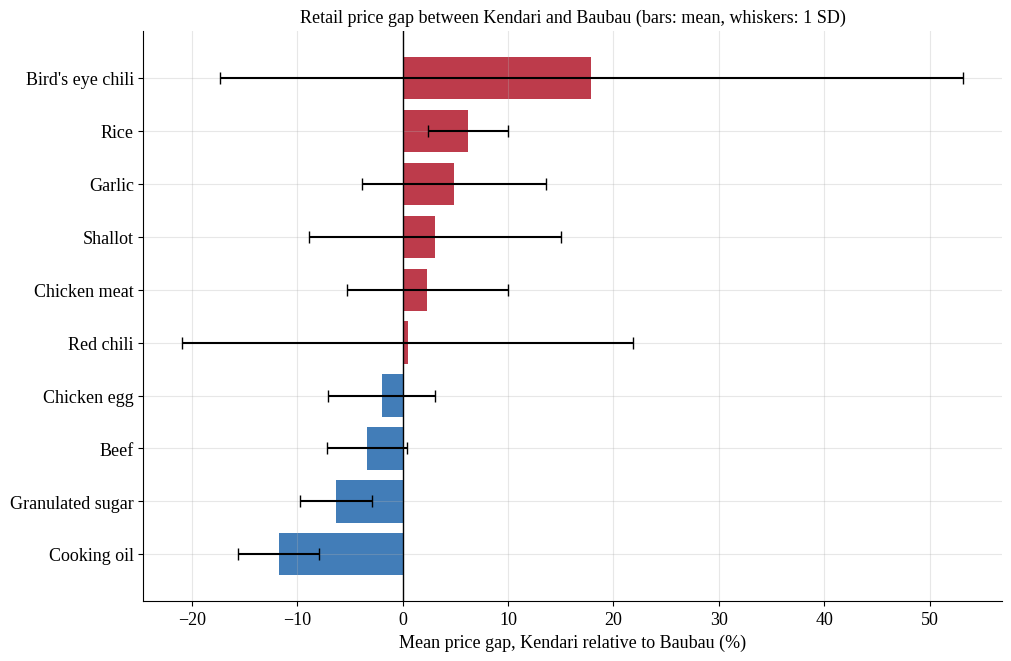

Selisih harga eceran Kendari terhadap Baubau dihitung untuk 10 komoditas agregat PIHPS pada 72 bulan pengamatan.
Harga di Kendari rata-rata lebih tinggi pada 6 komoditas, dengan selisih terbesar pada Cabai Rawit sebesar 17,9
persen. Harga di Baubau lebih tinggi pada 4 komoditas, dengan selisih terbesar pada Minyak Goreng sebesar 11,8
persen. Selisih di atas 10 persen paling sering terjadi pada Cabai Rawit, yaitu pada 72,2 persen bulan pengamatan.
Median waktu paruh selisih harga adalah 1,0 bulan (rentang 0,3 sampai 5,5 bulan). Artinya, separuh guncangan
selisih harga baru hilang setelah kurun waktu tersebut.



In [5]:
g = D['gap'].copy().sort_values(['commodity_group', 'obs_date'])
g['gap_pct'] = (np.exp(g['gap_log']) - 1) * 100
baris = []
for (kom_id, kom_en), x in g.groupby(['commodity_group', 'commodity_group_en']):
    s = x['gap_log'].to_numpy()
    phi, hl = np.nan, np.nan
    if len(s) >= 12:
        b, se, r2, n = ols(s[1:], s[:-1])
        phi = b[1]
        if 0 < phi < 1:
            hl = np.log(0.5) / np.log(phi)
    baris.append({'Commodity': kom_en, 'commodity_id': kom_id, 'Observations': len(s), 'Mean gap (%)': x['gap_pct'].mean(),
                  'Median gap (%)': x['gap_pct'].median(), 'Std. dev. (pp)': x['gap_pct'].std(),
                  'Months with gap above 10% in absolute value (%)': (x['gap_pct'].abs() > 10).mean() * 100,
                  'AR(1) coefficient': phi, 'Half-life (months)': hl})
T02 = pd.DataFrame(baris).sort_values('Mean gap (%)').reset_index(drop=True)
simpan_tabel(T02.drop(columns='commodity_id').round(3), 'T02_price_gap_kendari_baubau', 'Retail price gap between Kendari and Baubau (PIHPS)')
display(T02.drop(columns='commodity_id').round(2))

fig, ax = plt.subplots(figsize=(10, 6.5), constrained_layout=True)
warna = ['#b2182b' if v > 0 else '#2166ac' for v in T02['Mean gap (%)']]
ax.barh(T02['Commodity'], T02['Mean gap (%)'], xerr=T02['Std. dev. (pp)'], color=warna, alpha=0.85, capsize=4)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Mean price gap, Kendari relative to Baubau (%)')
ax.set_title('Retail price gap between Kendari and Baubau (bars: mean, whiskers: 1 SD)')
simpan_gambar(fig, 'F01_price_gap_kendari_baubau', 'Retail price gap between Kendari and Baubau')

lebih_k = T02[T02['Mean gap (%)'] > 0]
lebih_b = T02[T02['Mean gap (%)'] < 0]
kal = [f"Selisih harga eceran Kendari terhadap Baubau dihitung untuk {len(T02)} komoditas agregat PIHPS pada {g['period'].nunique()} bulan pengamatan."]
if len(lebih_k):
    t = lebih_k.iloc[-1]
    kal.append(f"Harga di Kendari rata-rata lebih tinggi pada {len(lebih_k)} komoditas, dengan selisih terbesar pada {t['commodity_id']} sebesar {angka(t['Mean gap (%)'], 1)} persen.")
if len(lebih_b):
    t = lebih_b.iloc[0]
    kal.append(f"Harga di Baubau lebih tinggi pada {len(lebih_b)} komoditas, dengan selisih terbesar pada {t['commodity_id']} sebesar {angka(abs(t['Mean gap (%)']), 1)} persen.")
sering = T02.sort_values('Months with gap above 10% in absolute value (%)', ascending=False).iloc[0]
kal.append(f"Selisih di atas 10 persen paling sering terjadi pada {sering['commodity_id']}, yaitu pada {angka(sering['Months with gap above 10% in absolute value (%)'], 1)} persen bulan pengamatan.")
hl = T02['Half-life (months)'].dropna()
if len(hl):
    kal.append(f"Median waktu paruh selisih harga adalah {angka(hl.median(), 1)} bulan (rentang {angka(hl.min(), 1)} sampai {angka(hl.max(), 1)} bulan). Artinya, separuh guncangan selisih harga baru hilang setelah kurun waktu tersebut.")
tafsir('F01', ' '.join(kal))

### 4.2 Perbedaan inflasi antarwilayah IHK di Sulawesi Tenggara

Sejak 2024, IHK Sulawesi Tenggara dihitung dari empat wilayah: Kota Kendari, Kota Baubau, Kabupaten Konawe, dan Kabupaten Kolaka. Inflasi tahunan dihitung ulang dari level IHK (tahun dasar 2022=100) karena satu kolom pada sheet sumber tidak konsisten dengan levelnya. Rentang sasaran 1,5 sampai 3,5 persen mengikuti PMK 31 Tahun 2024 (2,5 persen dengan deviasi 1 persen).

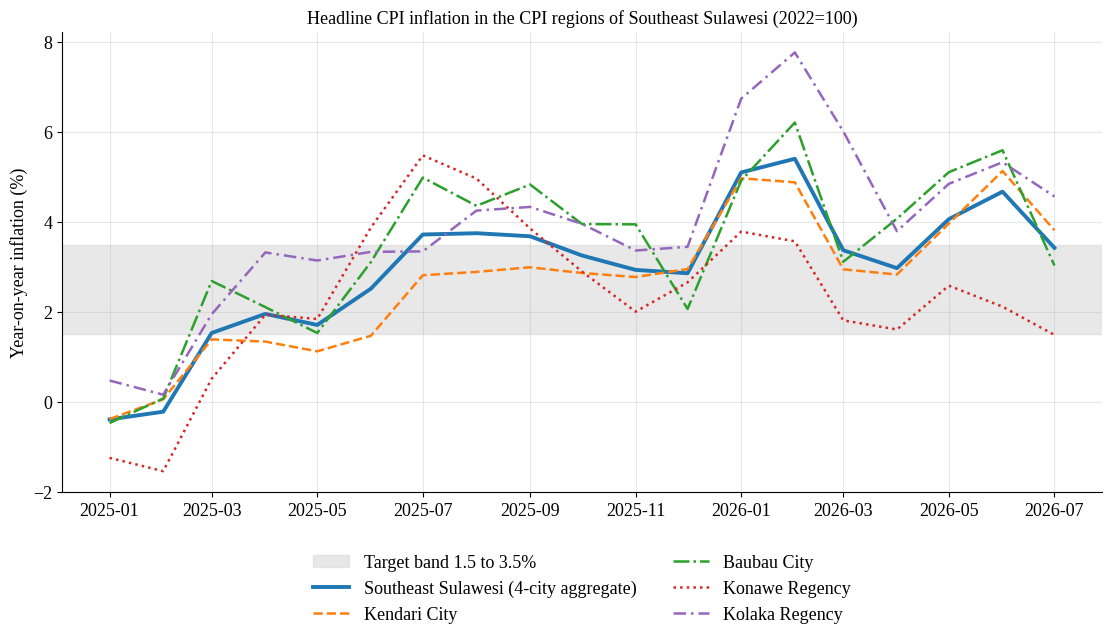

,Region,YoY inflation 2026-07 (%),Mean since 2025-01 (%),Minimum (%),Maximum (%),Months above 3.5%,Months below 1.5%
0,Southeast Sulawesi (4-city aggregate),3.43,2.97,-0.39,5.41,7,2
1,Kendari City,3.82,2.68,-0.38,5.14,5,6
2,Baubau City,3.03,3.44,-0.47,6.21,10,2
3,Konawe Regency,1.49,2.33,-1.54,5.48,6,4
4,Kolaka Regency,4.57,3.91,0.16,7.77,10,2


Pada 2026-07, inflasi tahunan gabungan empat wilayah IHK Sulawesi Tenggara sebesar 3,43 persen. Inflasi tertinggi
terjadi di Kabupaten Kolaka (4,57 persen) dan terendah di Kabupaten Konawe (1,49 persen), sehingga selisih
antarwilayah mencapai 3,08 poin persen. Sejak Januari 2025, angka gabungan berada di atas 3,5 persen selama 7 bulan
dan di bawah 1,5 persen selama 2 bulan.



In [6]:
cpi = D['cpi']
BATAS_BAWAH, BATAS_ATAS, TITIK_TENGAH = 1.5, 3.5, 2.5
umum = cpi[cpi['coicop_code'] == '0'].copy()
umum['label'] = umum['region_code'].map(REGION_EN)
yoy = umum[umum['period'] >= '2025-01'].pivot_table(index='period', columns='label', values='inflation_yoy_recomputed_pct')
urut = [REGION_EN[k] for k in [7400, 7471, 7472, 7403, 7404] if REGION_EN[k] in yoy.columns]
yoy = yoy[urut]

fig, ax = plt.subplots(figsize=(11, 6.3), constrained_layout=True)
ax.axhspan(BATAS_BAWAH, BATAS_ATAS, color='#d9d9d9', alpha=0.6, label='Target band 1.5 to 3.5%')
gaya = ['-', '--', '-.', ':', (0, (5, 2, 1, 2))]
tgl = pd.PeriodIndex(yoy.index, freq='M').to_timestamp()
for kol, ls in zip(yoy.columns, gaya):
    ax.plot(tgl, yoy[kol], ls=ls, lw=2.8 if kol.startswith('Southeast') else 1.8, label=kol)
ax.set_ylabel('Year-on-year inflation (%)')
ax.set_title('Headline CPI inflation in the CPI regions of Southeast Sulawesi (2022=100)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)
simpan_gambar(fig, 'F02_inflation_sultra_regions', 'Headline inflation in the CPI regions of Southeast Sulawesi')

akhir = yoy.index.max()
T03 = pd.DataFrame({'Region': yoy.columns, f'YoY inflation {akhir} (%)': yoy.loc[akhir].values, 'Mean since 2025-01 (%)': yoy.mean().values,
                    'Minimum (%)': yoy.min().values, 'Maximum (%)': yoy.max().values,
                    'Months above 3.5%': (yoy > BATAS_ATAS).sum().values, 'Months below 1.5%': (yoy < BATAS_BAWAH).sum().values})
simpan_tabel(T03.round(3), 'T03_inflation_sultra_regions', 'Headline inflation in the CPI regions of Southeast Sulawesi')
display(T03.round(2))

ag = T03.iloc[0]
sisa = T03.iloc[1:].sort_values(f'YoY inflation {akhir} (%)')
tafsir('F02', f"Pada {akhir}, inflasi tahunan gabungan empat wilayah IHK Sulawesi Tenggara sebesar {angka(ag.iloc[1])} persen. "
       f"Inflasi tertinggi terjadi di {LABEL_ID[sisa.iloc[-1]['Region']]} ({angka(sisa.iloc[-1].iloc[1])} persen) dan terendah di {LABEL_ID[sisa.iloc[0]['Region']]} ({angka(sisa.iloc[0].iloc[1])} persen), "
       f"sehingga selisih antarwilayah mencapai {angka(sisa.iloc[-1].iloc[1] - sisa.iloc[0].iloc[1])} poin persen. "
       f"Sejak Januari 2025, angka gabungan berada di atas 3,5 persen selama {int(ag['Months above 3.5%'])} bulan dan di bawah 1,5 persen selama {int(ag['Months below 1.5%'])} bulan.")

### 4.3 Posisi inflasi makanan Sulawesi Tenggara di antara kota IHK nasional

Kita membandingkan inflasi tahunan subkelompok Makanan (kode 011) di empat wilayah IHK Sulawesi Tenggara dengan seluruh kota IHK nasional (150 kabupaten/kota, 2022=100). Peringkat 1 berarti inflasi tertinggi.

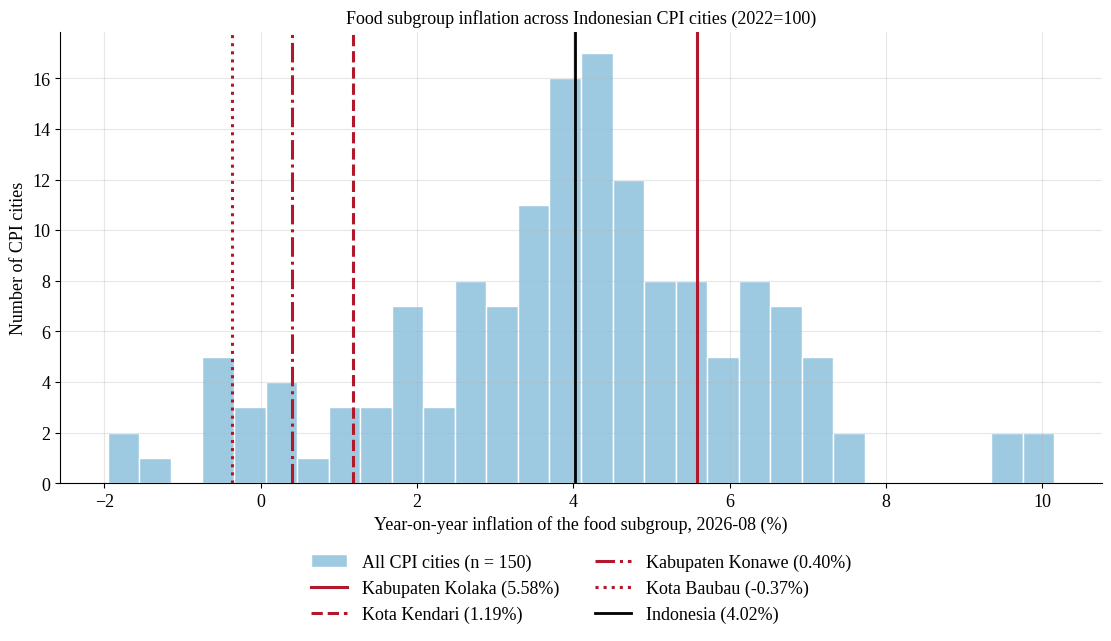

,CPI city,Food subgroup yoy 2026-08 (%),Rank (1 = highest),Percentile
0,KAB KOLAKA,5.58,32.0,79.33
1,KOTA KENDARI,1.19,132.0,12.67
2,KAB KONAWE,0.40,136.0,10.00
3,KOTA BAU BAU,-0.37,143.0,5.33
4,Indonesia,4.02,NaN,NaN
5,Mean of Sulawesi CPI cities,2.97,NaN,NaN
6,Median of all CPI cities,4.11,NaN,NaN


Pada 2026-08, inflasi tahunan subkelompok Makanan di 150 kota IHK memiliki median 4,11 persen. Kabupaten Kolaka
berada pada peringkat 32 dengan inflasi 5,58 persen (persentil 79). Kota Kendari berada pada peringkat 132 dengan
inflasi 1,19 persen (persentil 13). Kabupaten Konawe berada pada peringkat 136 dengan inflasi 0,40 persen
(persentil 10). Kota Baubau berada pada peringkat 143 dengan inflasi -0,37 persen (persentil 5). Angka nasional
sebesar 4,02 persen dan rata-rata kota IHK di Pulau Sulawesi sebesar 2,97 persen.



In [7]:
n22 = D['nat22']
mk = n22[n22['coicop_code'] == '011'][['city_name', 'province_code', 'province_name', 'region_code', 'period', 'cpi']].copy()
jumlah_kota = mk.groupby('period')['city_name'].nunique()
akhir = jumlah_kota[jumlah_kota >= 100].index.max()
dasar = geser(akhir, -12)
a = mk[mk['period'] == akhir].set_index('city_name')['cpi']
b = mk[mk['period'] == dasar].set_index('city_name')['cpi']
yy = ((a / b - 1) * 100).dropna().rename('yoy').reset_index()
meta = mk.drop_duplicates('city_name').set_index('city_name')[['province_code', 'province_name', 'region_code']]
yy = yy.join(meta, on='city_name')
kota = yy[yy['province_code'] != 0].copy()
kota['Rank (1 = highest)'] = kota['yoy'].rank(ascending=False, method='min').astype(int)
kota['Percentile'] = kota['yoy'].rank(pct=True) * 100
sultra = kota[kota['region_code'].notna()].sort_values('yoy', ascending=False)
nasional = yy.loc[yy['province_code'] == 0, 'yoy']
sulawesi = kota[kota['province_code'].between(71, 76)]

fig, ax = plt.subplots(figsize=(11, 6.3), constrained_layout=True)
ax.hist(kota['yoy'], bins=30, color='#9ecae1', edgecolor='white', label=f'All CPI cities (n = {len(kota)})')
gaya = ['-', '--', '-.', ':']
for (i, r), ls in zip(sultra.reset_index(drop=True).iterrows(), gaya):
    ax.axvline(r['yoy'], color='#b2182b', ls=ls, lw=2.2, label=f"{nama_kota(r['city_name'])} ({r['yoy']:.2f}%)")
if len(nasional):
    ax.axvline(nasional.iloc[0], color='black', lw=2, label=f'Indonesia ({nasional.iloc[0]:.2f}%)')
ax.set_xlabel(f'Year-on-year inflation of the food subgroup, {akhir} (%)')
ax.set_ylabel('Number of CPI cities')
ax.set_title('Food subgroup inflation across Indonesian CPI cities (2022=100)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
simpan_gambar(fig, 'F03_food_inflation_national_position', 'Food subgroup inflation across Indonesian CPI cities')

T04 = sultra[['city_name', 'yoy', 'Rank (1 = highest)', 'Percentile']].rename(columns={'city_name': 'CPI city', 'yoy': f'Food subgroup yoy {akhir} (%)'})
tambahan = pd.DataFrame([{'CPI city': 'Indonesia', f'Food subgroup yoy {akhir} (%)': nasional.iloc[0] if len(nasional) else np.nan},
                         {'CPI city': 'Mean of Sulawesi CPI cities', f'Food subgroup yoy {akhir} (%)': sulawesi['yoy'].mean()},
                         {'CPI city': 'Median of all CPI cities', f'Food subgroup yoy {akhir} (%)': kota['yoy'].median()}])
T04 = pd.concat([T04, tambahan], ignore_index=True)
simpan_tabel(T04.round(3), 'T04_food_inflation_national_position', 'Position of Southeast Sulawesi food inflation among CPI cities')
display(T04.round(2))

kal = [f"Pada {akhir}, inflasi tahunan subkelompok Makanan di {len(kota)} kota IHK memiliki median {angka(kota['yoy'].median())} persen."]
for _, r in sultra.iterrows():
    kal.append(f"{nama_kota(r['city_name'])} berada pada peringkat {int(r['Rank (1 = highest)'])} dengan inflasi {angka(r['yoy'])} persen (persentil {angka(r['Percentile'], 0)}).")
if len(nasional):
    kal.append(f"Angka nasional sebesar {angka(nasional.iloc[0])} persen dan rata-rata kota IHK di Pulau Sulawesi sebesar {angka(sulawesi['yoy'].mean())} persen.")
tafsir('F03', ' '.join(kal))

### 4.4 Sebaran harga produsen ikan antarkabupaten

Harga produsen tertimbang tiap jenis ikan dihitung dari nilai dibagi volume produksi KKP 2024 per kabupaten/kota. Koefisien variasi antarwilayah menunjukkan seberapa jauh harga di tingkat nelayan terpisah antarpasar. Kita juga membandingkan harga rata-rata tertimbang di gugus daratan dan kepulauan.

,Species (KKP name),Regencies/cities,Volume (tonnes),Weighted mean price (IDR/kg),Minimum price (IDR/kg),Maximum price (IDR/kg),Coefficient of variation (%),Mainland mean price (IDR/kg),Island mean price (IDR/kg)
5,TERI NASI GACER,7,9130.5,30518.4,10001.7,35000.1,48.0,18337.8,31410.6
1,TUNA SIRIP KUNING,12,12215.3,26127.6,14999.9,49999.0,37.2,25431.5,26380.0
4,TERI GEPENG,7,9216.8,12017.6,7000.1,19999.8,36.9,19865.9,8512.6
7,TEMBANG GARIS KUNING,15,7677.1,12113.6,8819.5,25000.0,33.1,12534.7,11573.2
6,KUWE,11,8363.6,37480.4,19997.2,49999.7,29.4,34003.6,39686.9
3,KEMBUNG GEPENG,12,9219.1,26738.0,17262.5,40003.8,28.2,26975.4,26526.2
0,CAKALANG,15,19975.4,21077.8,14998.5,35000.7,26.1,22335.9,19873.5
2,KEMBUNG LELAKI,9,9444.5,28939.1,19999.5,39638.0,21.7,26563.2,32505.1


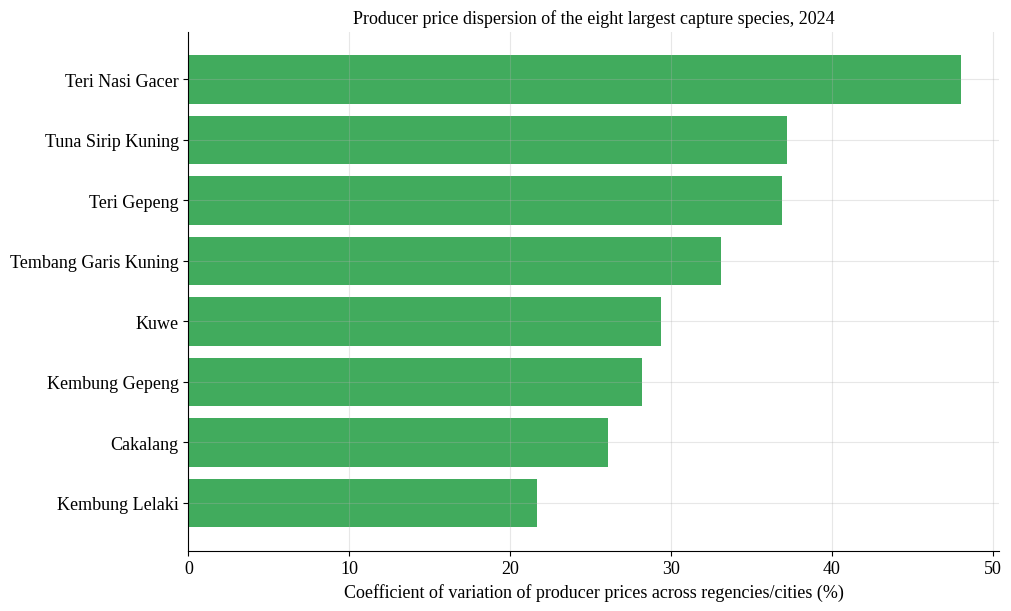

Di antara delapan jenis ikan dengan volume tangkapan terbesar, sebaran harga produsen antarkabupaten paling lebar
terjadi pada Teri Nasi Gacer dengan koefisien variasi 48,0 persen; harga terendah Rp 10.002 per kg dan tertinggi Rp
35.000 per kg. Harga rata-rata tertimbang di gugus kepulauan lebih rendah daripada di gugus daratan pada 4 dari 8
jenis ikan.



In [8]:
k = D['kkp']
gugus = D['spat'][['region_code', 'cluster']]
top_sp = k.groupby('species')['volume_ton'].sum().nlargest(8).index.tolist()
baris = []
for sp in top_sp:
    x = k[k['species'] == sp].groupby('region_code').agg(v=('volume_ton', 'sum'), nilai=('value_million_rp', 'sum')).reset_index()
    x = x[x['v'] > 0].merge(gugus, on='region_code', how='left')
    x['price'] = x['nilai'] * 1e6 / (x['v'] * 1000)
    dar, pul = x[x['cluster'] == 'mainland'], x[x['cluster'] == 'island']
    baris.append({'Species (KKP name)': sp, 'Regencies/cities': len(x), 'Volume (tonnes)': x['v'].sum(),
                  'Weighted mean price (IDR/kg)': np.average(x['price'], weights=x['v']),
                  'Minimum price (IDR/kg)': x['price'].min(), 'Maximum price (IDR/kg)': x['price'].max(),
                  'Coefficient of variation (%)': x['price'].std() / x['price'].mean() * 100,
                  'Mainland mean price (IDR/kg)': np.average(dar['price'], weights=dar['v']) if len(dar) else np.nan,
                  'Island mean price (IDR/kg)': np.average(pul['price'], weights=pul['v']) if len(pul) else np.nan})
T05 = pd.DataFrame(baris).sort_values('Coefficient of variation (%)', ascending=False)
simpan_tabel(T05.round(2), 'T05_fish_producer_price_dispersion', 'Dispersion of fish producer prices across regencies/cities, 2024')
display(T05.round(1))

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
t5 = T05.sort_values('Coefficient of variation (%)')
ax.barh(t5['Species (KKP name)'].str.title(), t5['Coefficient of variation (%)'], color='#41ab5d')
ax.set_xlabel('Coefficient of variation of producer prices across regencies/cities (%)')
ax.set_title('Producer price dispersion of the eight largest capture species, 2024')
simpan_gambar(fig, 'F04_fish_producer_price_dispersion', 'Producer price dispersion of the largest capture species')

atas = T05.iloc[0]
pul_lebih_murah = int((T05['Island mean price (IDR/kg)'] < T05['Mainland mean price (IDR/kg)']).sum())
tafsir('F04', f"Di antara delapan jenis ikan dengan volume tangkapan terbesar, sebaran harga produsen antarkabupaten paling lebar terjadi pada {atas['Species (KKP name)'].title()} "
       f"dengan koefisien variasi {angka(atas['Coefficient of variation (%)'], 1)} persen; harga terendah Rp {angka(atas['Minimum price (IDR/kg)'], 0)} per kg dan tertinggi Rp {angka(atas['Maximum price (IDR/kg)'], 0)} per kg. "
       f"Harga rata-rata tertimbang di gugus kepulauan lebih rendah daripada di gugus daratan pada {pul_lebih_murah} dari {len(T05)} jenis ikan.")

## Langkah 5. Penyerapan permintaan dan hilirisasi perikanan

### 5.1 Produksi perikanan tangkap 2024

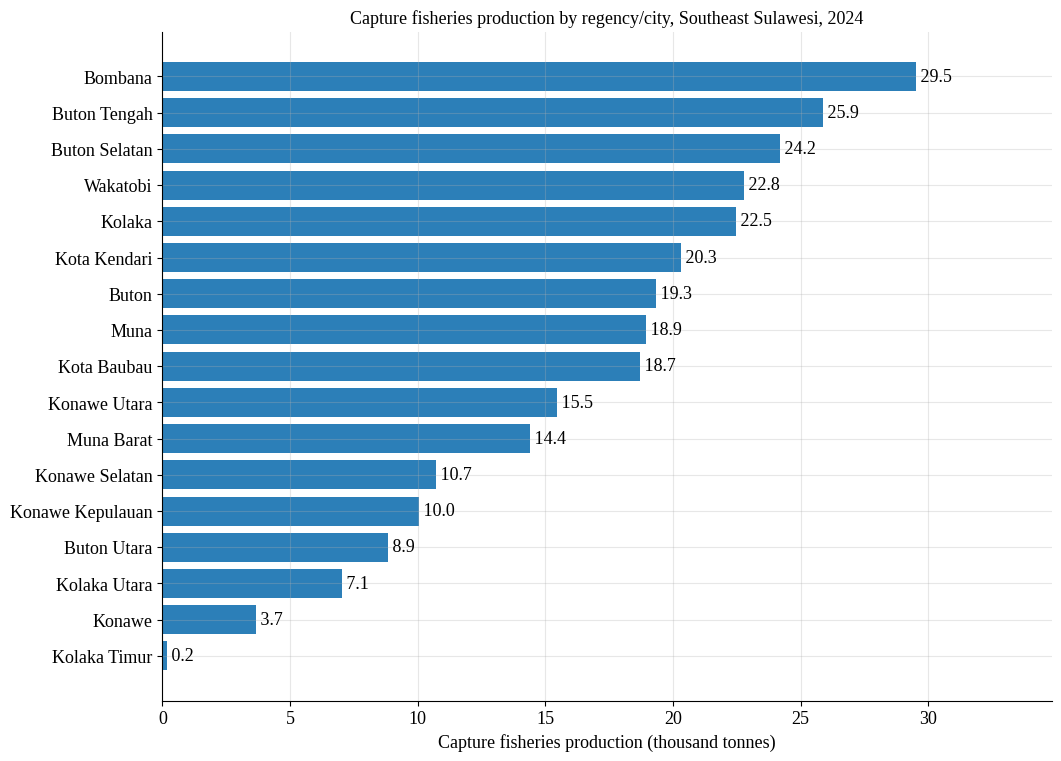

,Fish group (KKP),Volume (tonnes),Value (IDR million),Share of volume (%),Mean price (IDR/kg)
0,TERI,30867.5,622756,11.3,20175.1
1,KEMBUNG,22513.0,636869,8.3,28288.9
2,LAYANG,21675.3,331061,8.0,15273.6
3,CAKALANG,19975.4,421037,7.3,21077.8
4,TONGKOL,16749.5,300130,6.1,17918.8
5,KUWE,16506.6,641759,6.1,38878.8
6,TUNA,16185.7,454090,5.9,28055.0
7,LENCAM,13611.3,413869,5.0,30406.3
8,KERAPU,11387.5,604340,4.2,53070.3
9,SELAR,10574.8,230811,3.9,21826.5


Produksi perikanan tangkap Sulawesi Tenggara pada 2024 sebesar 272.457 ton. Tiga kabupaten/kota terbesar adalah
Bombana (10,8 persen), Buton Tengah (9,5 persen), Buton Selatan (8,9 persen), dengan pangsa gabungan 29,2 persen.
Tiga kelompok ikan terbesar adalah Teri (11,3 persen), Kembung (8,3 persen), Layang (8,0 persen).



In [9]:
kk = D['kkpk'].sort_values('volume_ton')
fig, ax = plt.subplots(figsize=(10.5, 7.5), constrained_layout=True)
nilai = kk['volume_ton'] / 1000
ax.barh(kk['region_name'], nilai, color='#2c7fb8')
for yy_, v in enumerate(nilai):
    ax.text(v, yy_, f' {v:,.1f}', va='center', fontsize=13)
ax.set_xlim(0, nilai.max() * 1.18)
ax.set_xlabel('Capture fisheries production (thousand tonnes)')
ax.set_title('Capture fisheries production by regency/city, Southeast Sulawesi, 2024')
simpan_gambar(fig, 'F05_capture_production_by_region', 'Capture fisheries production by regency/city, 2024')

kp = D['kkp'].groupby('fish_group').agg(volume=('volume_ton', 'sum'), value=('value_million_rp', 'sum')).sort_values('volume', ascending=False)
kp['Share of volume (%)'] = kp['volume'] / kp['volume'].sum() * 100
kp['Mean price (IDR/kg)'] = kp['value'] * 1e6 / (kp['volume'] * 1000)
T06 = kp.head(10).reset_index().rename(columns={'fish_group': 'Fish group (KKP)', 'volume': 'Volume (tonnes)', 'value': 'Value (IDR million)'})
simpan_tabel(T06.round(2), 'T06_top_fish_groups', 'Ten largest fish groups by volume, 2024')
display(T06.round(1))

tot = kk['volume_ton'].sum()
top3 = kk.sort_values('volume_ton', ascending=False).head(3)
tafsir('F05', f"Produksi perikanan tangkap Sulawesi Tenggara pada 2024 sebesar {angka(tot, 0)} ton. Tiga kabupaten/kota terbesar adalah "
       + ', '.join(f"{r['region_name']} ({angka(r['share_volume_pct'], 1)} persen)" for _, r in top3.iterrows())
       + f", dengan pangsa gabungan {angka(top3['share_volume_pct'].sum(), 1)} persen. Tiga kelompok ikan terbesar adalah "
       + ', '.join(f"{r['Fish group (KKP)'].title()} ({angka(r['Share of volume (%)'], 1)} persen)" for _, r in T06.head(3).iterrows()) + ".")

### 5.2 Ekspor ikan segar (HS 03) dan olahan (HS 16), serta jalur ekspor

Nilai satuan (US$ per kg) dipakai sebagai petunjuk nilai tambah: produk olahan (HS 16) semestinya bernilai satuan lebih tinggi daripada ikan segar atau beku (HS 03). Pangsa ekspor tidak langsung menunjukkan porsi ekspor asal Sulawesi Tenggara yang dimuat di pelabuhan provinsi lain.

,Year,HS 03 exports (USD million),HS 16 exports (USD million),HS 03 unit value (USD/kg),HS 16 unit value (USD/kg),Indirect share of all exports (%),Note
0,2014,7.06,0.00,NaN,NaN,NaN,
1,2015,7.60,0.00,NaN,NaN,NaN,
2,2016,11.64,0.00,NaN,NaN,NaN,
3,2017,23.57,0.00,NaN,NaN,NaN,
4,2018,26.30,0.02,NaN,NaN,23.77,
5,2019,19.33,0.01,NaN,NaN,14.79,
6,2020,20.10,0.05,6.62,2.63,9.94,
7,2021,29.86,2.10,8.19,43.15,9.18,
8,2022,33.06,2.95,9.57,33.96,7.25,
9,2023,33.02,4.26,8.92,28.34,7.84,


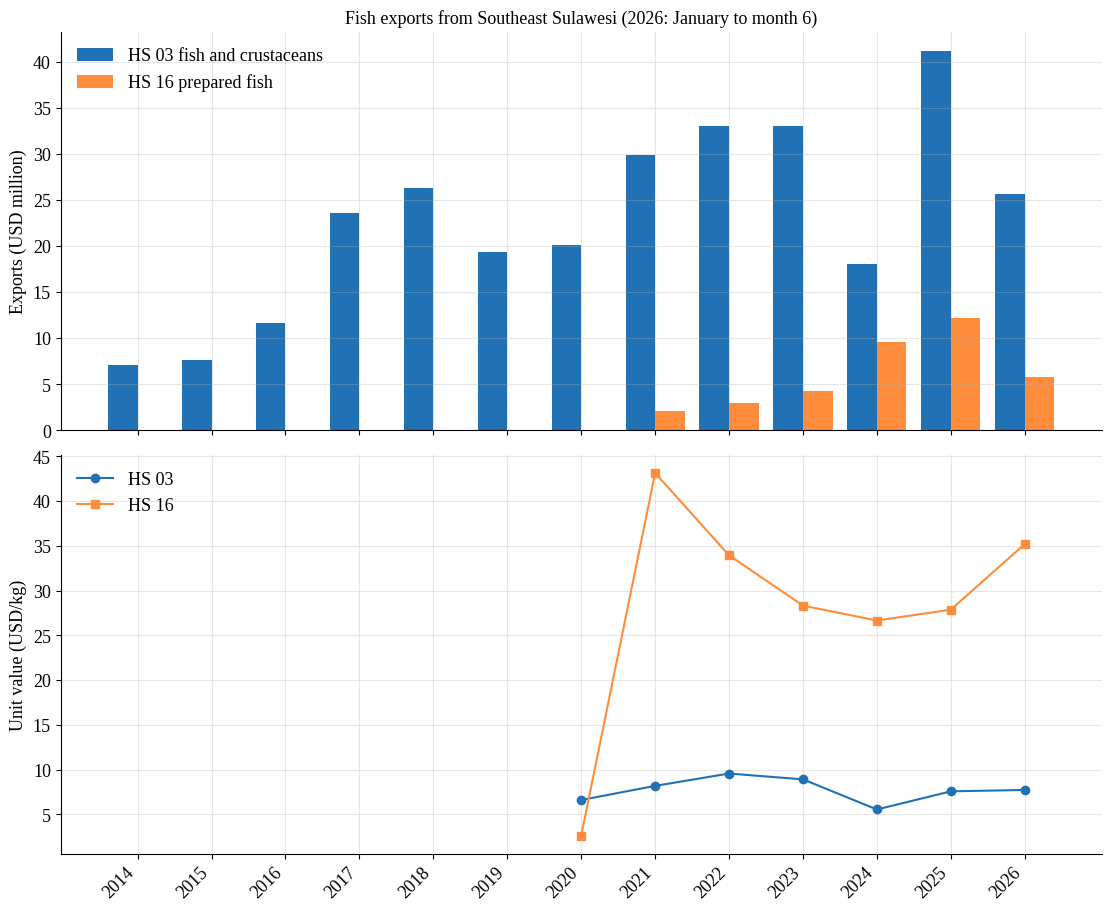

Pada 2025, ekspor HS 03 bernilai US$ 41,19 juta dan ekspor HS 16 bernilai US$ 12,15 juta. Nilai satuan HS 16
sebesar US$ 27,88 per kg, atau 3,68 kali nilai satuan HS 03 (US$ 7,59 per kg). Pada tahun yang sama, 6,3 persen
nilai seluruh ekspor asal Sulawesi Tenggara dimuat di pelabuhan provinsi lain.



In [10]:
tr = D['trade']
ek = tr[(tr['flow'] == 'export') & (~tr['is_oil_gas'].astype(bool)) & (tr['hs2'].isin(['03', '16']))].copy()
th_akhir = int(ek['year'].max())
bl_akhir = int(ek.loc[ek['year'] == th_akhir, 'month'].max())
ann = ek.groupby(['year', 'hs2']).agg(value_usd=('value_usd', 'sum'), volume_kg=('volume_kg', 'sum')).reset_index()
ann['unit_value'] = np.where(ann['volume_kg'] > 0, ann['value_usd'] / ann['volume_kg'], np.nan)
wide = ann.pivot_table(index='year', columns='hs2', values=['value_usd', 'unit_value'])
ch = D['chan']
ch = ch[ch['flow'] == 'export'].pivot_table(index='year', columns='channel', values='value_thousand_usd', aggfunc='sum')
ch['indirect_share'] = ch['indirect'] / (ch['direct'] + ch['indirect']) * 100

T07 = pd.DataFrame({'Year': wide.index,
                    'HS 03 exports (USD million)': wide[('value_usd', '03')].values / 1e6 if ('value_usd', '03') in wide else np.nan,
                    'HS 16 exports (USD million)': wide[('value_usd', '16')].values / 1e6 if ('value_usd', '16') in wide else np.nan,
                    'HS 03 unit value (USD/kg)': wide[('unit_value', '03')].values if ('unit_value', '03') in wide else np.nan,
                    'HS 16 unit value (USD/kg)': wide[('unit_value', '16')].values if ('unit_value', '16') in wide else np.nan})
T07 = T07.merge(ch['indirect_share'].rename('Indirect share of all exports (%)').reset_index().rename(columns={'year': 'Year'}), on='Year', how='left')
T07['Note'] = np.where(T07['Year'] == th_akhir, f'January to month {bl_akhir} only', '')
simpan_tabel(T07.round(3), 'T07_fish_exports_and_channels', 'Fish exports (HS 03 and HS 16) and indirect export share')
display(T07.round(2))

fig, axs = plt.subplots(2, 1, figsize=(11, 9), constrained_layout=True, sharex=True)
xx = np.arange(len(T07))
axs[0].bar(xx - 0.2, T07['HS 03 exports (USD million)'].fillna(0), width=0.4, color='#2171b5', label='HS 03 fish and crustaceans')
axs[0].bar(xx + 0.2, T07['HS 16 exports (USD million)'].fillna(0), width=0.4, color='#fd8d3c', label='HS 16 prepared fish')
axs[0].set_ylabel('Exports (USD million)')
axs[0].set_title(f'Fish exports from Southeast Sulawesi ({th_akhir}: January to month {bl_akhir})')
axs[0].legend(loc='upper left', frameon=False)
axs[1].plot(xx, T07['HS 03 unit value (USD/kg)'], marker='o', color='#2171b5', label='HS 03')
axs[1].plot(xx, T07['HS 16 unit value (USD/kg)'], marker='s', color='#fd8d3c', label='HS 16')
axs[1].set_ylabel('Unit value (USD/kg)')
axs[1].legend(loc='upper left', frameon=False)
axs[1].set_xticks(xx)
axs[1].set_xticklabels(T07['Year'].astype(str), rotation=45, ha='right')
simpan_gambar(fig, 'F06_fish_exports', 'Fish exports and unit values')

penuh = T07[T07['Year'] < th_akhir].dropna(subset=['HS 03 exports (USD million)'])
r = penuh.iloc[-1]
kal = [f"Pada {int(r['Year'])}, ekspor HS 03 bernilai US$ {angka(r['HS 03 exports (USD million)'])} juta dan ekspor HS 16 bernilai US$ {angka(r['HS 16 exports (USD million)'])} juta."]
if np.isfinite(r['HS 03 unit value (USD/kg)']) and np.isfinite(r['HS 16 unit value (USD/kg)']) and r['HS 03 unit value (USD/kg)'] > 0:
    kal.append(f"Nilai satuan HS 16 sebesar US$ {angka(r['HS 16 unit value (USD/kg)'])} per kg, atau {angka(r['HS 16 unit value (USD/kg)'] / r['HS 03 unit value (USD/kg)'])} kali nilai satuan HS 03 (US$ {angka(r['HS 03 unit value (USD/kg)'])} per kg).")
if np.isfinite(r['Indirect share of all exports (%)']):
    kal.append(f"Pada tahun yang sama, {angka(r['Indirect share of all exports (%)'], 1)} persen nilai seluruh ekspor asal Sulawesi Tenggara dimuat di pelabuhan provinsi lain.")
tafsir('F06', ' '.join(kal))

### 5.3 Struktur permintaan akhir kabupaten/kota

Pangsa konsumsi rumah tangga dan konsumsi pemerintah dalam PDRB atas dasar harga berlaku menunjukkan sumber permintaan domestik yang dapat menyerap produksi pangan dan perikanan daerah.

,Regency/city,GRDP (IDR billion),Household consumption share (%),Npish consumption share (%),Government consumption share (%),Gross fixed capital formation share (%),Change in inventories share (%),Net exports share (%)
15,Muna Barat,3766.1,87.6,1.3,14.4,43.2,-0.4,-46.1
6,Kolaka Timur,6541.9,65.7,0.8,9.0,34.1,0.5,-10.2
14,Muna,10090.1,64.6,1.1,15.1,30.7,-0.1,-11.5
12,Kota Baubau,12969.7,61.5,1.1,13.8,42.3,-0.1,-18.7
3,Buton Tengah,3415.1,60.1,1.1,12.2,37.2,-1.1,-9.6
2,Buton Selatan,4110.7,58.9,1.3,11.7,35.2,0.4,-7.5
13,Kota Kendari,32128.6,58.8,1.1,26.3,39.7,2.1,-28.1
1,Buton,5575.6,56.5,1.3,14.6,34.0,-2.7,-3.7
10,Konawe Selatan,19224.8,53.0,1.5,9.6,30.4,0.7,4.7
16,Wakatobi,6494.7,49.8,1.8,19.6,28.5,0.8,-0.7


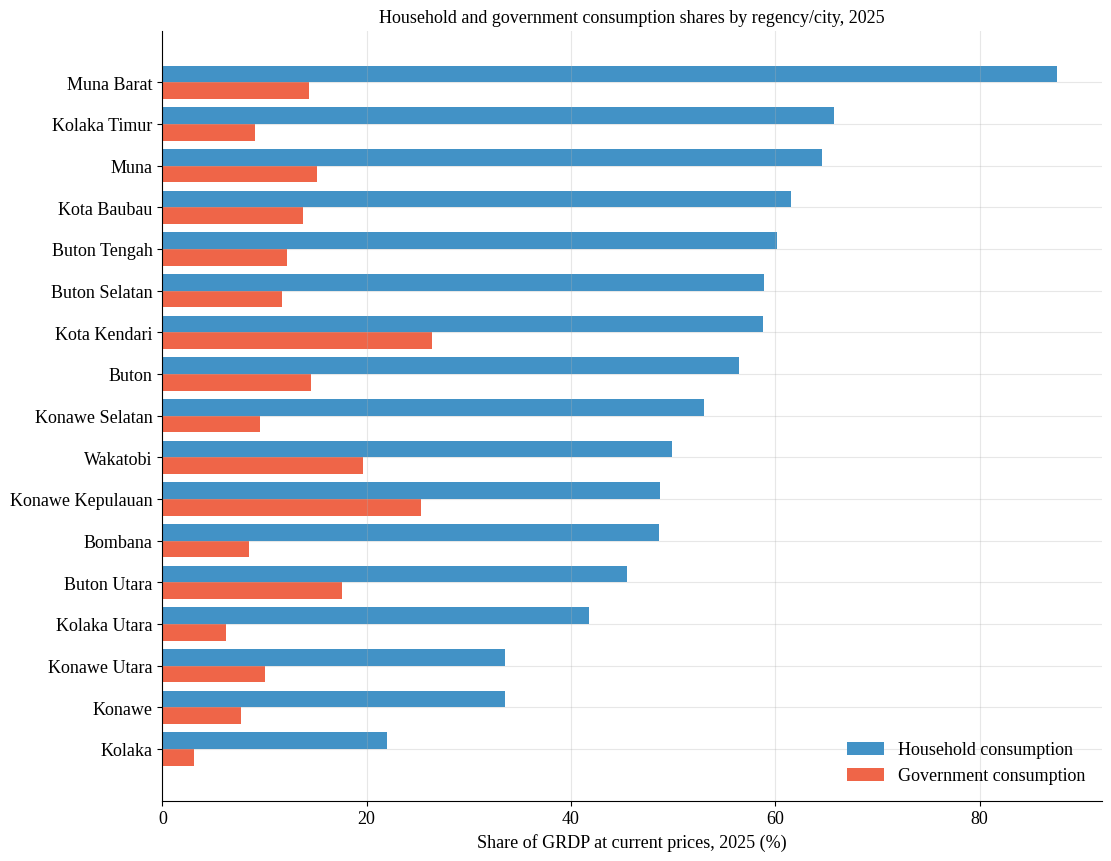

Pada 2025, pangsa konsumsi rumah tangga terhadap PDRB tertinggi terdapat di Muna Barat (87,6 persen) dan terendah
di Kolaka (22,0 persen). Pangsa konsumsi pemerintah tertinggi terdapat di Kota Kendari (26,3 persen). Sebanyak 11
dari 17 kabupaten/kota mencatat ekspor neto negatif, artinya kebutuhan barang dan jasanya lebih banyak dipenuhi
dari luar wilayah.



In [11]:
ge = D['gexp']
th = int(ge['year'].max())
s = ge[(ge['price_basis'] == 'current') & (ge['year'] == th)]
pv = s.pivot_table(index='kabkota_name', columns='component', values='value_billion_rp', aggfunc='sum')
komp = ['household_consumption', 'npish_consumption', 'government_consumption', 'gross_fixed_capital_formation', 'change_in_inventories', 'net_exports']
T08 = pd.DataFrame({'Regency/city': pv.index, 'GRDP (IDR billion)': pv['grdp_total'].values})
for c in komp:
    if c in pv:
        T08[c.replace('_', ' ').capitalize() + ' share (%)'] = (pv[c] / pv['grdp_total'] * 100).values
T08 = T08.sort_values('Household consumption share (%)', ascending=False)
simpan_tabel(T08.round(3), 'T08_grdp_expenditure_structure', f'GRDP expenditure structure by regency/city, {th}')
display(T08.round(1))

fig, ax = plt.subplots(figsize=(11, 8.5), constrained_layout=True)
t8 = T08.sort_values('Household consumption share (%)')
yy_ = np.arange(len(t8))
ax.barh(yy_ + 0.2, t8['Household consumption share (%)'], height=0.4, color='#4292c6', label='Household consumption')
ax.barh(yy_ - 0.2, t8['Government consumption share (%)'], height=0.4, color='#ef6548', label='Government consumption')
ax.set_yticks(yy_)
ax.set_yticklabels(t8['Regency/city'])
ax.set_xlabel(f'Share of GRDP at current prices, {th} (%)')
ax.set_title(f'Household and government consumption shares by regency/city, {th}')
ax.legend(loc='lower right', frameon=False)
simpan_gambar(fig, 'F07_consumption_shares', 'Household and government consumption shares')

neg = int((T08['Net exports share (%)'] < 0).sum()) if 'Net exports share (%)' in T08 else 0
tafsir('F07', f"Pada {th}, pangsa konsumsi rumah tangga terhadap PDRB tertinggi terdapat di {T08.iloc[0]['Regency/city']} ({angka(T08.iloc[0]['Household consumption share (%)'], 1)} persen) "
       f"dan terendah di {T08.iloc[-1]['Regency/city']} ({angka(T08.iloc[-1]['Household consumption share (%)'], 1)} persen). "
       f"Pangsa konsumsi pemerintah tertinggi terdapat di {T08.sort_values('Government consumption share (%)').iloc[-1]['Regency/city']} "
       f"({angka(T08['Government consumption share (%)'].max(), 1)} persen). Sebanyak {neg} dari {len(T08)} kabupaten/kota mencatat ekspor neto negatif, "
       f"artinya kebutuhan barang dan jasanya lebih banyak dipenuhi dari luar wilayah.")

### 5.4 Kebutuhan ikan program MBG

Kebutuhan ikan utuh dari program Makan Bergizi Gratis dihitung dari parameter program dan komposisi gizi:

$$Q = B \times H \times f \times \frac{p}{c / 100} \times \frac{1}{e} \times 10^{-6}$$

dengan $Q$ kebutuhan ikan utuh (ton per tahun), $B$ jumlah penerima manfaat, $H$ hari layanan per tahun, $f$ frekuensi menu ikan, $p$ protein hewani per porsi (gram), $c$ kandungan protein ikan tongkol per 100 gram bagian dapat dimakan, dan $e$ proporsi bagian dapat dimakan. Tiga skenario memakai batas bawah, titik tengah, dan batas atas parameter yang berupa rentang.

In [12]:
par = D['par'].set_index('parameter')['value'].astype(str)
def nilai_param(nama):
    return [float(v.replace(',', '.')) for v in re.findall(r'\d+(?:[.,]\d+)?', par.get(nama, ''))]
B = nilai_param('MBG_penerima_manfaat_31Jul2026')[0]
prot = nilai_param('MBG_protein_hewani_per_porsi')
hari = nilai_param('asumsi_hari_layanan_per_tahun')
frek = nilai_param('asumsi_frekuensi_menu_ikan')[0]
c_ikan = nilai_param('protein_tongkol_segar_per_100g_BDD')[0]
bdd = nilai_param('asumsi_bagian_dapat_dimakan_ikan')[0]
skenario = {'Low': (min(prot), min(hari)), 'Base': (np.mean(prot), np.mean(hari)), 'High': (max(prot), max(hari))}
prod_total = D['kkp']['volume_ton'].sum()
prod_tc = D['kkp'][D['kkp']['fish_group'].str.contains('TONGKOL|CAKALANG', case=False)]['volume_ton'].sum()
baris = []
for nama, (p_, h_) in skenario.items():
    q = B * h_ * frek * (p_ / (c_ikan / 100)) / bdd / 1e6
    baris.append({'Scenario': nama, 'Beneficiaries': B, 'Service days per year': h_, 'Fish menu frequency': frek,
                  'Animal protein per portion (g)': p_, 'Whole fish required (tonnes/year)': q,
                  'Share of 2024 capture production (%)': q / prod_total * 100,
                  'Share of 2024 tuna-type catch, tongkol and cakalang (%)': q / prod_tc * 100})
T09 = pd.DataFrame(baris)
simpan_tabel(T09.round(3), 'T09_mbg_fish_requirement', 'Fish requirement of the free nutritious meal programme')
display(T09.round(2))
bs = T09.set_index('Scenario').loc['Base']
tafsir('T09', f"Dengan {angka(B, 0)} penerima manfaat (31 Juli 2026), menu ikan pada {angka(frek * 100, 0)} persen hari layanan, dan protein hewani {angka(bs['Animal protein per portion (g)'], 1)} gram per porsi, "
       f"kebutuhan ikan utuh program MBG sekitar {angka(bs['Whole fish required (tonnes/year)'], 0)} ton per tahun "
       f"(rentang {angka(T09['Whole fish required (tonnes/year)'].min(), 0)} sampai {angka(T09['Whole fish required (tonnes/year)'].max(), 0)} ton). "
       f"Angka dasar setara {angka(bs['Share of 2024 capture production (%)'], 2)} persen produksi tangkap 2024 dan {angka(bs['Share of 2024 tuna-type catch, tongkol and cakalang (%)'], 2)} persen tangkapan kelompok tongkol dan cakalang. "
       f"Program ini menambah permintaan terjamin, tetapi porsinya kecil dibanding pasokan, sehingga penyerapan produksi tetap bergantung pada rumah tangga, industri pengolahan, dan ekspor.")

,Scenario,Beneficiaries,Service days per year,Fish menu frequency,Animal protein per portion (g),Whole fish required (tonnes/year),Share of 2024 capture production (%),"Share of 2024 tuna-type catch, tongkol and cakalang (%)"
0,Low,704066.0,240.0,0.3,15.0,4096.94,1.50,11.16
1,Base,704066.0,246.0,0.3,17.5,4899.25,1.80,13.34
2,High,704066.0,252.0,0.3,20.0,5735.71,2.11,15.62


Dengan 704.066 penerima manfaat (31 Juli 2026), menu ikan pada 30 persen hari layanan, dan protein hewani 17,5 gram
per porsi, kebutuhan ikan utuh program MBG sekitar 4.899 ton per tahun (rentang 4.097 sampai 5.736 ton). Angka
dasar setara 1,80 persen produksi tangkap 2024 dan 13,34 persen tangkapan kelompok tongkol dan cakalang. Program
ini menambah permintaan terjamin, tetapi porsinya kecil dibanding pasokan, sehingga penyerapan produksi tetap
bergantung pada rumah tangga, industri pengolahan, dan ekspor.



### 5.5 Nilai tukar nelayan dan pembudidaya ikan

Nilai tukar dihitung sebagai indeks harga yang diterima dibagi indeks harga yang dibayar, dikali 100 (tahun dasar 2018=100). Nilai di atas 100 berarti harga yang diterima naik lebih cepat daripada harga yang dibayar sejak tahun dasar.

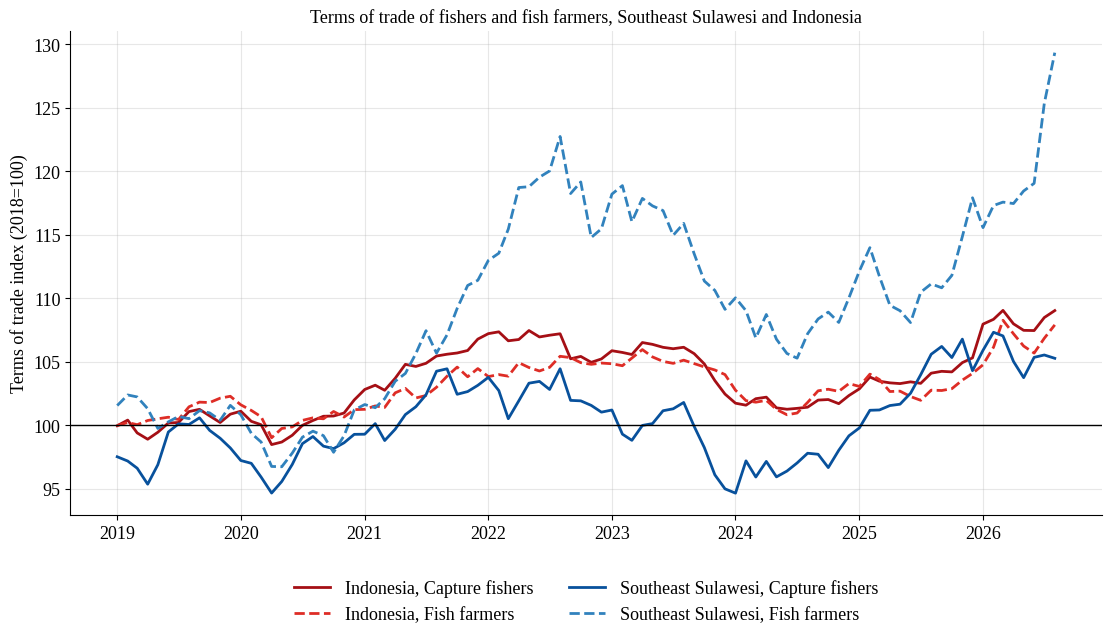

period,Series,Index 2025-08,Index 2026-08,Change over 12 months (%),Mean 2025
0,"Indonesia, Capture fishers",104.11,109.04,4.73,103.86
1,"Indonesia, Fish farmers",102.77,107.91,5.00,103.03
2,"Southeast Sulawesi, Capture fishers",105.60,105.28,-0.30,103.35
3,"Southeast Sulawesi, Fish farmers",111.14,129.35,16.38,111.79


Nilai tukar nelayan tangkap Sulawesi Tenggara pada 2026-08 sebesar 105,28 (turun 0,30 persen dalam 12 bulan). Nilai
tukar pembudidaya ikan Sulawesi Tenggara pada 2026-08 sebesar 129,35 (naik 16,38 persen dalam 12 bulan). Sebagai
pembanding, nilai tukar nelayan tangkap nasional sebesar 109,04.



In [13]:
pilih = {'capture_fishers': 'Capture fishers', 'fish_farmers': 'Fish farmers'}
s1 = D['ibit_s'][D['ibit_s']['subsector'].isin(pilih)].assign(area='Southeast Sulawesi')
s2 = D['ibit_n'][(D['ibit_n']['province_code'] == 0) & D['ibit_n']['subsector'].isin(pilih)].assign(area='Indonesia')
nt = pd.concat([s1, s2])[['area', 'subsector', 'period', 'it', 'ib', 'terms_of_trade_computed']]
nt['label'] = nt['area'] + ', ' + nt['subsector'].map(pilih)

fig, ax = plt.subplots(figsize=(11, 6.3), constrained_layout=True)
gaya = {'Southeast Sulawesi, Capture fishers': ('#08519c', '-'), 'Southeast Sulawesi, Fish farmers': ('#3182bd', '--'),
        'Indonesia, Capture fishers': ('#a50f15', '-'), 'Indonesia, Fish farmers': ('#de2d26', '--')}
for lab, x in nt.sort_values('period').groupby('label'):
    wr, ls = gaya.get(lab, ('grey', '-'))
    ax.plot(pd.PeriodIndex(x['period'], freq='M').to_timestamp(), x['terms_of_trade_computed'], color=wr, ls=ls, lw=2, label=lab)
ax.axhline(100, color='black', lw=1)
ax.set_ylabel('Terms of trade index (2018=100)')
ax.set_title('Terms of trade of fishers and fish farmers, Southeast Sulawesi and Indonesia')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)
simpan_gambar(fig, 'F08_fishers_terms_of_trade', 'Terms of trade of fishers and fish farmers')

akhir = nt['period'].max()
lalu = geser(akhir, -12)
T10 = (nt[nt['period'].isin([akhir, lalu])].pivot_table(index='label', columns='period', values='terms_of_trade_computed').reset_index()
       .rename(columns={'label': 'Series', akhir: f'Index {akhir}', lalu: f'Index {lalu}'}))
T10['Change over 12 months (%)'] = (T10[f'Index {akhir}'] / T10[f'Index {lalu}'] - 1) * 100
rata = nt[nt['period'].str.startswith(str(int(akhir[:4]) - 1))].groupby('label')['terms_of_trade_computed'].mean()
T10[f'Mean {int(akhir[:4]) - 1}'] = T10['Series'].map(rata)
simpan_tabel(T10.round(3), 'T10_fishers_terms_of_trade', 'Terms of trade of fishers and fish farmers')
display(T10.round(2))
st = T10.set_index('Series')
kal = []
for lab in ['Southeast Sulawesi, Capture fishers', 'Southeast Sulawesi, Fish farmers']:
    if lab in st.index:
        kal.append(f"Nilai tukar {('nelayan tangkap' if 'Capture' in lab else 'pembudidaya ikan')} Sulawesi Tenggara pada {akhir} sebesar {angka(st.loc[lab, f'Index {akhir}'])} "
                   f"({'naik' if st.loc[lab, 'Change over 12 months (%)'] >= 0 else 'turun'} {angka(abs(st.loc[lab, 'Change over 12 months (%)']))} persen dalam 12 bulan).")
if 'Indonesia, Capture fishers' in st.index:
    kal.append(f"Sebagai pembanding, nilai tukar nelayan tangkap nasional sebesar {angka(st.loc['Indonesia, Capture fishers', f'Index {akhir}'])}.")
tafsir('F08', ' '.join(kal))

## Langkah 6. Inflasi dan bobot IHK

IHK BPS memakai rumus Laspeyres termodifikasi. Akibatnya, indeks agregat sama dengan rata-rata tertimbang indeks penyusunnya dengan bobot nilai konsumsi tahun dasar:

$$I_{t} = \sum_{i} w_{i}\, I_{i,t}, \qquad \sum_{i} w_{i} = 1$$

Inflasi tahunan dan andil (sumbangan) komponen $i$ terhadap inflasi tahunan dihitung sebagai:

$$\pi_{t} = 100\left(\frac{I_{t}}{I_{t-12}} - 1\right), \qquad c_{i,t} = 100\, \frac{w_{i}\,(I_{i,t} - I_{i,t-12})}{I_{t-12}}, \qquad \sum_{i} c_{i,t} = \pi_{t}$$

Bobot resmi SBH 2022 tidak tersedia, sehingga kita memakai bobot tersirat hasil estimasi kuadrat terkecil nonnegatif pada paket data. Metode itu divalidasi dengan membandingkan hasil estimasinya pada seri 2018=100 dengan bobot resmi SBH 2018 (IMF dkk., 2020; Lawson dan Hanson, 1995).

,City,Level,Weights,Mean absolute difference (pp),Maximum absolute difference (pp)
0,Kota Baubau,Group in general CPI,10,0.644,1.724
1,Kota Baubau,Subgroup in group,37,0.212,1.895
2,Kota Kendari,Group in general CPI,10,0.063,0.193
3,Kota Kendari,Subgroup in group,38,0.032,0.128


region_code,Code,Group,Southeast Sulawesi,Konawe,Kolaka,Kendari,Baubau
0,01,"Food, beverages and tobacco",31.63,41.14,34.07,28.25,27.59
1,02,Clothing and footwear,5.58,6.60,5.69,5.56,5.08
2,03,"Housing, water, electricity and household fuels",12.18,11.62,11.50,11.27,16.74
3,04,"Furnishings, household equipment and maintenance",4.85,5.94,4.62,3.95,4.10
4,05,Health,2.80,1.78,3.03,3.50,2.31
5,06,Transport,14.86,11.50,14.52,15.24,18.90
6,07,"Information, communication and financial services",8.16,5.86,8.32,8.48,9.42
7,08,"Recreation, sport and culture",1.35,1.59,1.29,1.63,1.20
8,09,Education,4.36,2.40,3.67,5.51,3.33
9,10,Food and beverage serving services,6.29,6.53,5.35,7.10,5.09


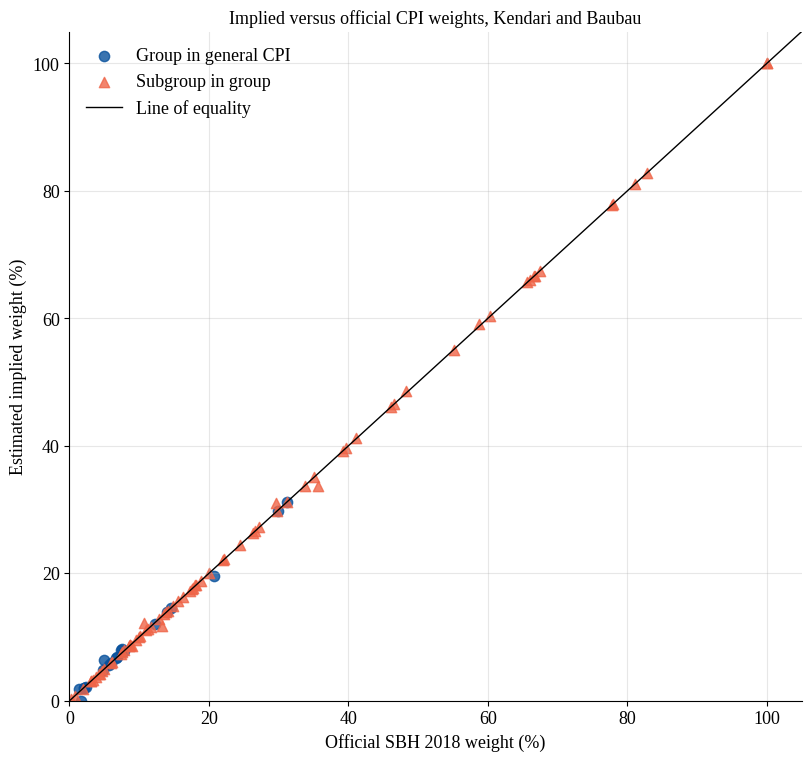

Validasi pada seri 2018=100 menghasilkan rata-rata selisih mutlak 0,35 poin persen untuk bobot kelompok dan 0,12
poin persen untuk bobot subkelompok, dengan korelasi 0,9998 terhadap bobot resmi. Pada seri 2022=100, bobot
kelompok terbesar di Sulawesi Tenggara adalah makanan, minuman, dan tembakau (31,63 persen), transportasi (14,86
persen), dan perumahan, air, listrik, dan bahan bakar rumah tangga (12,18 persen).



In [14]:
w = D['w22']
wv = D['wval']
val = wv[wv['published_sbh2018_weight_in_parent'].notna()].copy()
val['Level'] = np.where(val['parent_code'] == '0', 'Group in general CPI', 'Subgroup in group')
T11 = val.groupby(['region_name', 'Level']).agg(Weights=('coicop_code', 'size'), MAE_pp=('abs_diff_pp', 'mean'),
                                               Max_abs_diff_pp=('abs_diff_pp', 'max')).reset_index()
T11 = T11.rename(columns={'region_name': 'City', 'MAE_pp': 'Mean absolute difference (pp)', 'Max_abs_diff_pp': 'Maximum absolute difference (pp)'})
korelasi = val[['estimated_weight_in_parent', 'published_sbh2018_weight_in_parent']].corr().iloc[0, 1]
simpan_tabel(T11.round(3), 'T11_weight_method_validation', 'Validation of implied CPI weights against official SBH 2018 weights')
display(T11.round(3))

gw = w[w['level'] == 1].pivot_table(index='coicop_code', columns='region_code', values='weight_in_general') * 100
gw = gw.rename(columns={7400: 'Southeast Sulawesi', 7471: 'Kendari', 7472: 'Baubau', 7403: 'Konawe', 7404: 'Kolaka'})
T12 = gw.reset_index().rename(columns={'coicop_code': 'Code'})
T12.insert(1, 'Group', T12['Code'].map(GROUP_EN))
simpan_tabel(T12.round(3), 'T12_implied_group_weights_2022', 'Implied group weights in the general CPI, 2022=100 (%)')
display(T12.round(2))

fig, ax = plt.subplots(figsize=(8, 7.5), constrained_layout=True)
for lv, mk_, wr in [('Group in general CPI', 'o', '#08519c'), ('Subgroup in group', '^', '#ef6548')]:
    x = val[val['Level'] == lv]
    ax.scatter(x['published_sbh2018_weight_in_parent'] * 100, x['estimated_weight_in_parent'] * 100, marker=mk_, s=55, alpha=0.8, color=wr, label=lv)
batas = max(val['published_sbh2018_weight_in_parent'].max(), val['estimated_weight_in_parent'].max()) * 100 * 1.05
ax.plot([0, batas], [0, batas], color='black', lw=1, label='Line of equality')
ax.set_xlim(0, batas); ax.set_ylim(0, batas)
ax.set_xlabel('Official SBH 2018 weight (%)')
ax.set_ylabel('Estimated implied weight (%)')
ax.set_title('Implied versus official CPI weights, Kendari and Baubau')
ax.legend(loc='upper left', frameon=False)
simpan_gambar(fig, 'F09_weight_validation', 'Implied versus official CPI weights')

t12 = T12.set_index('Code')['Southeast Sulawesi'].sort_values(ascending=False)
g_ = T11[T11['Level'] == 'Group in general CPI']
tafsir('F09', f"Validasi pada seri 2018=100 menghasilkan rata-rata selisih mutlak {angka(g_['Mean absolute difference (pp)'].mean())} poin persen untuk bobot kelompok "
       f"dan {angka(T11[T11['Level'] == 'Subgroup in group']['Mean absolute difference (pp)'].mean())} poin persen untuk bobot subkelompok, dengan korelasi {angka(korelasi, 4)} terhadap bobot resmi. "
       f"Pada seri 2022=100, bobot kelompok terbesar di Sulawesi Tenggara adalah {GROUP_ID[t12.index[0]]} ({angka(t12.iloc[0])} persen), "
       f"{GROUP_ID[t12.index[1]]} ({angka(t12.iloc[1])} persen), dan {GROUP_ID[t12.index[2]]} ({angka(t12.iloc[2])} persen).")

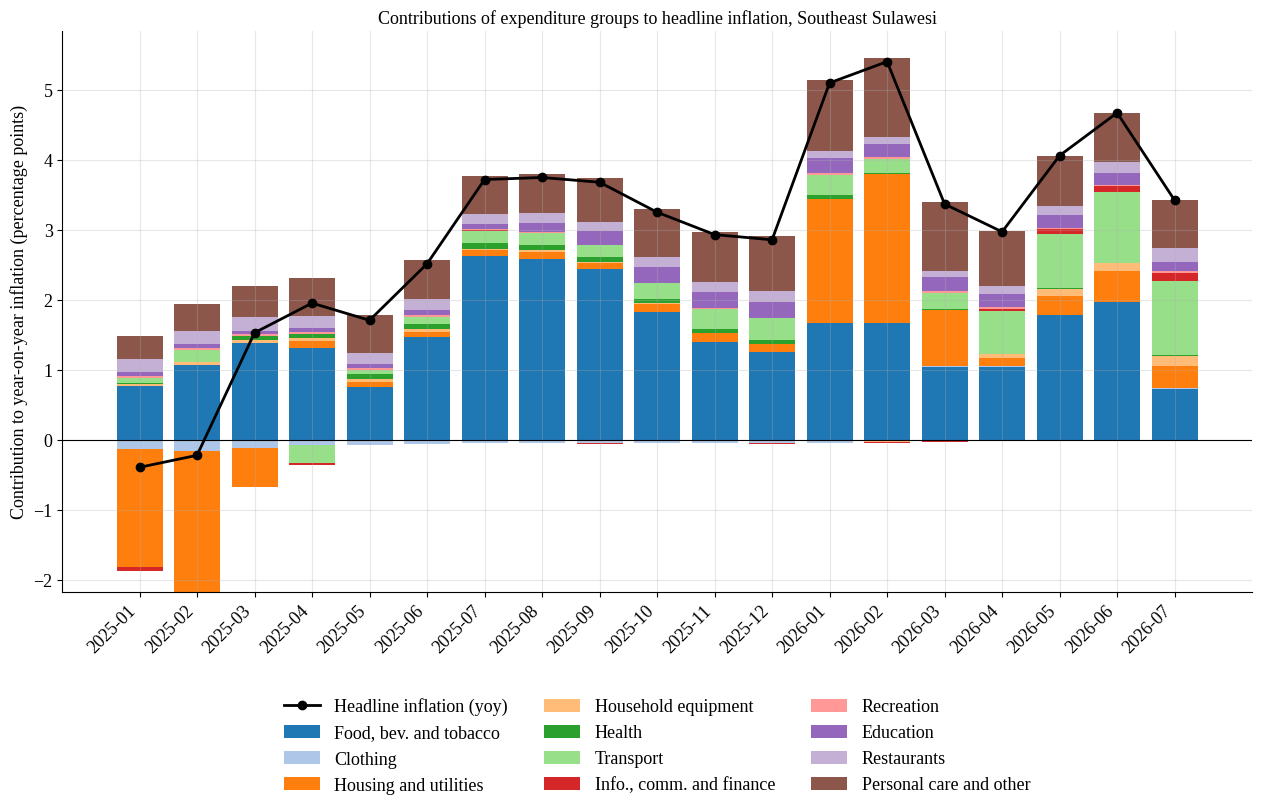

,Code,Group,Contribution 2026-07 (pp),Share of headline inflation 2026-07 (%)
5,06,Transport,1.056,30.818
0,01,"Food, beverages and tobacco",0.732,21.366
10,11,Personal care and other services,0.684,19.961
2,03,"Housing, water, electricity and household fuels",0.325,9.484
9,10,Food and beverage serving services,0.188,5.497
3,04,"Furnishings, household equipment and maintenance",0.143,4.183
8,09,Education,0.140,4.088
6,07,"Information, communication and financial services",0.111,3.252
7,08,"Recreation, sport and culture",0.023,0.665
4,05,Health,0.012,0.354


Pada 2026-07, inflasi tahunan gabungan Sulawesi Tenggara sebesar 3,43 persen. Penyumbang terbesar adalah kelompok
transportasi (1,06 poin persen), kelompok makanan, minuman, dan tembakau (0,73 poin persen), kelompok perawatan
pribadi dan jasa lainnya (0,68 poin persen). Selisih antara jumlah andil dan inflasi aktual paling besar 0,008 poin
persen sepanjang periode, sehingga penguraian dengan bobot tersirat konsisten dengan angka resmi.



In [15]:
reg = 7400
c7 = cpi[cpi['region_code'] == reg]
gen = c7[c7['coicop_code'] == '0'].set_index('period')['cpi'].sort_index()
grp = c7[c7['level'] == 1].pivot_table(index='period', columns='coicop_code', values='cpi').sort_index()
bw = w[(w['region_code'] == reg) & (w['level'] == 1)].set_index('coicop_code')['weight_in_general']
grp = grp[[c for c in bw.index if c in grp.columns]]
per = [p for p in grp.index if geser(p, -12) in grp.index]
kontr = pd.DataFrame({p: 100 * bw * (grp.loc[p] - grp.loc[geser(p, -12)]) / gen.loc[geser(p, -12)] for p in per}).T
aktual = pd.Series({p: 100 * (gen.loc[p] / gen.loc[geser(p, -12)] - 1) for p in per})
residu = aktual - kontr.sum(axis=1)
kp_ = kontr.loc[[p for p in kontr.index if p >= '2025-01']]

fig, ax = plt.subplots(figsize=(12.5, 8), constrained_layout=True)
xx = np.arange(len(kp_))
basis_pos, basis_neg = np.zeros(len(kp_)), np.zeros(len(kp_))
peta = plt.get_cmap('tab20')
for i, col in enumerate(kp_.columns):
    v = kp_[col].to_numpy()
    vp, vn = np.where(v > 0, v, 0), np.where(v < 0, v, 0)
    ax.bar(xx, vp, bottom=basis_pos, color=peta(i), width=0.8, label=GROUP_SHORT.get(col, col))
    ax.bar(xx, vn, bottom=basis_neg, color=peta(i), width=0.8)
    basis_pos += vp
    basis_neg += vn
ax.plot(xx, aktual.loc[kp_.index], color='black', marker='o', lw=2, label='Headline inflation (yoy)')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(xx)
ax.set_xticklabels(kp_.index, rotation=45, ha='right')
ax.set_ylabel('Contribution to year-on-year inflation (percentage points)')
ax.set_title('Contributions of expenditure groups to headline inflation, Southeast Sulawesi')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), ncol=3, frameon=False)
simpan_gambar(fig, 'F10_inflation_contributions', 'Contributions of expenditure groups to headline inflation')

akhir = kp_.index[-1]
T13 = pd.DataFrame({'Code': kontr.columns, 'Group': [GROUP_EN.get(c, c) for c in kontr.columns],
                    f'Contribution {akhir} (pp)': kontr.loc[akhir].values})
T13[f'Share of headline inflation {akhir} (%)'] = T13[f'Contribution {akhir} (pp)'] / aktual.loc[akhir] * 100
T13 = T13.sort_values(f'Contribution {akhir} (pp)', ascending=False)
simpan_tabel(T13.round(4), 'T13_inflation_contributions_latest', f'Contributions to headline inflation, {akhir}')
display(T13.round(3))
atas3 = T13.head(3)
tafsir('F10', f"Pada {akhir}, inflasi tahunan gabungan Sulawesi Tenggara sebesar {angka(aktual.loc[akhir])} persen. Penyumbang terbesar adalah "
       + ', '.join(f"kelompok {GROUP_ID.get(r['Code'], r['Group'])} ({angka(r[f'Contribution {akhir} (pp)'])} poin persen)" for _, r in atas3.iterrows())
       + f". Selisih antara jumlah andil dan inflasi aktual paling besar {angka(residu.abs().max(), 3)} poin persen sepanjang periode, sehingga penguraian dengan bobot tersirat konsisten dengan angka resmi.")

In [16]:
bmc = D['bmc']
brg = D['brg']
ikan = bmc[bmc['block_code'] == '01.1.103'].set_index('region_name')
kunci = ['BERAS', 'IKAN TONGKOL', 'IKAN CAKALANG', 'IKAN LAYANG', 'IKAN KEMBUNG', 'CABAI RAWIT', 'BAWANG MERAH', 'TELUR AYAM RAS', 'DAGING AYAM RAS']
bb = brg[brg['item_name'].str.upper().str.startswith(tuple(kunci))].copy()
T14 = bb[['region_name', 'item_name', 'weight_sbh2018_pct', 'weight_in_general_2022_bridged_pct']].rename(columns={
    'region_name': 'City', 'item_name': 'Commodity (BPS name)', 'weight_sbh2018_pct': 'SBH 2018 weight (%)',
    'weight_in_general_2022_bridged_pct': 'Bridged 2022 weight (%)'})
T14['Effect of a 10% price rise on monthly inflation (pp)'] = T14['Bridged 2022 weight (%)'] * 0.10
T14 = T14.sort_values(['City', 'Bridged 2022 weight (%)'], ascending=[True, False])
simpan_tabel(T14.round(4), 'T14_key_food_weights', 'Weights of key food commodities in the CPI')
display(T14.round(3))
kal = []
for kota_, r in ikan.iterrows():
    kal.append(f"Di {kota_}, blok ikan segar berbobot {angka(r['weight_in_general_pct'])} persen dari IHK (SBH 2018) atau {angka(r['share_in_bm_pct'], 1)} persen dari kelompok Bahan Makanan, "
               f"sehingga kenaikan harga ikan segar 10 persen menambah inflasi bulanan sekitar {angka(r['weight_in_general_pct'] * 0.10)} poin persen.")
top_i = T14.sort_values('Bridged 2022 weight (%)', ascending=False).iloc[0]
kal.append(f"Di antara komoditas kunci, perkiraan bobot 2022 terbesar ada pada {top_i['Commodity (BPS name)'].title()} di {top_i['City']} ({angka(top_i['Bridged 2022 weight (%)'])} persen).")
tafsir('T14', ' '.join(kal))

,City,Commodity (BPS name),SBH 2018 weight (%),Bridged 2022 weight (%),Effect of a 10% price rise on monthly inflation (pp)
390,Kota Baubau,BERAS,5.134,4.850,0.485
405,Kota Baubau,IKAN LAYANG/ IKAN BENGGOL,2.465,2.329,0.233
401,Kota Baubau,IKAN CAKALANG/ IKAN SISIK,0.818,0.772,0.077
404,Kota Baubau,IKAN KEMBUNG/IKAN GEMBUNG/ IKAN BANYAR/IKAN GE...,0.756,0.715,0.071
413,Kota Baubau,TELUR AYAM RAS,0.698,0.659,0.066
450,Kota Baubau,BAWANG MERAH,0.349,0.330,0.033
460,Kota Baubau,CABAI RAWIT,0.319,0.301,0.030
396,Kota Baubau,DAGING AYAM RAS,0.221,0.209,0.021
0,Kota Kendari,BERAS,4.678,4.283,0.428
18,Kota Kendari,IKAN KEMBUNG/IKAN GEMBUNG/ IKAN BANYAR/IKAN GE...,1.462,1.339,0.134


Di Kota Kendari, blok ikan segar berbobot 6,72 persen dari IHK (SBH 2018) atau 28,7 persen dari kelompok Bahan
Makanan, sehingga kenaikan harga ikan segar 10 persen menambah inflasi bulanan sekitar 0,67 poin persen. Di Kota
Baubau, blok ikan segar berbobot 7,69 persen dari IHK (SBH 2018) atau 32,9 persen dari kelompok Bahan Makanan,
sehingga kenaikan harga ikan segar 10 persen menambah inflasi bulanan sekitar 0,77 poin persen. Di antara komoditas
kunci, perkiraan bobot 2022 terbesar ada pada Beras di Kota Baubau (4,85 persen).



## Langkah 7. Sistem simulasi

### 7.1 Kerangka

Sistem simulasi kita terdiri atas dua lapis.

**Lapis pertama, akuntansi IHK.** Proyeksi dasar indeks tiap subkelompok dibuat dengan metode rata-rata musiman: perubahan logaritma bulan $m$ ke depan sama dengan rata-rata perubahan pada bulan kalender yang sama di tahun-tahun pengamatan (Hyndman dan Athanasopoulos, 2021). Indeks umum proyeksi disusun kembali dengan bobot tersirat. Sasaran inflasi tahunan $\pi^{*}$ pada bulan $T$ lalu dibalik menjadi indeks umum yang dibutuhkan:

$$I^{*}_{T} = I_{T-12}\,(1 + \pi^{*}/100), \qquad \Delta I = I^{*}_{T} - I^{b}_{T}$$

Bila hanya tuas harga $j$ yang disesuaikan, perubahan harga yang dibutuhkan relatif terhadap lintasan dasar adalah $\Delta P_{j}/P_{j} = \Delta I / (w_{j} I^{b}_{j,T})$. Untuk beberapa tuas sekaligus kita mencari penyesuaian $x_{j}$ yang paling kecil secara keseluruhan:

$$\min_{x} \sum_{j} \kappa_{j} x_{j}^{2} \quad \text{dengan syarat} \quad \sum_{j} w_{j} I^{b}_{j,T}\,(e^{x_{j}} - 1) = \Delta I, \quad x_{j}^{min} \le x_{j} \le x_{j}^{max}$$

Hasilnya diterjemahkan menjadi batas pertumbuhan harga bulanan tiap tuas sampai bulan sasaran.

**Lapis kedua, sistem dinamis pasar ikan.** Model stok dan aliran bulanan (Sterman, 2000) menghubungkan harga produsen ikan $p_{t}$, harga konsumen $c_{t}$, permintaan $d_{t}$, kapasitas tangkap $K_{t}$, dan pasokan $q_{t}$. Semua variabel dinyatakan sebagai rasio terhadap lintasan dasar (lintasan dasar = 1):

$$c_{t} = (1 - m_{0})\,p_{t} + m_{0}(1 - f_{t}), \qquad d_{t} = c_{t}^{\varepsilon_{d}}(1 + a_{t}), \qquad q_{t} = K_{t} + s_{t}$$

$$p_{t+1} = p_{t}\,\exp\{\phi\,(d_{t} - q_{t})\}, \qquad K_{t+1} = K_{t} + (n_{t}^{\varepsilon_{s}} - K_{t})/\tau$$

Tuas kebijakan adalah $f$ (penurunan margin distribusi lewat logistik dan rantai dingin), $s$ (operasi pasar berupa pelepasan stok ikan, sebagai bagian dari pasokan), $a$ (tambahan penyerapan permintaan terjamin dari MBG dan industri pengolahan), dan $g$ (moderasi pertumbuhan harga pangan lain per bulan). Dampaknya diteruskan ke variabel sosial ekonomi:

$$\frac{IHK_{t}}{IHK^{b}_{t}} = 1 + w_{ikan}(c_{t} - 1) + w_{lain}(e^{-g\,t} - 1), \qquad n_{t} = \frac{p_{t}^{\theta}}{(IHK_{t}/IHK^{b}_{t})^{\psi}}$$

$$\frac{GK_{t}}{GK^{b}_{t}} = s_{f}\,\frac{w_{ikan} c_{t} + w_{lain} e^{-g t}}{w_{ikan} + w_{lain}} + (1 - s_{f}), \qquad P0_{t} = \Phi\left(z_{0} + \frac{\ln(GK_{t}/GK^{b}_{t})}{\sigma}\right)$$

dengan $n_{t}$ rasio nilai tukar nelayan, $GK$ garis kemiskinan, $s_{f}$ pangsa garis kemiskinan makanan, $\Phi$ fungsi distribusi normal baku, $z_{0} = \Phi^{-1}(P0_{0})$, dan $\sigma = \sqrt{2}\,\Phi^{-1}\{(1 + Gini)/2\}$. Persamaan terakhir mengikuti pendekatan distribusi log-normal (López dan Servén, 2006) dengan pendapatan nominal dianggap tetap terhadap lintasan dasar.

Model ini memuat tiga umpan balik penyeimbang. Pertama, harga produsen yang tinggi menaikkan nilai tukar nelayan, lalu menambah kapasitas tangkap dan pasokan, sehingga harga turun kembali dengan tunda waktu $\tau$. Kedua, harga konsumen yang tinggi menekan permintaan. Ketiga, operasi pasar menurunkan harga produsen dan nilai tukar nelayan, sehingga kapasitas menyusut dan menekan pasokan pada bulan-bulan berikutnya. Umpan balik ketiga inilah yang membuat kebijakan stabilisasi harga menghadapi pertukaran antara kepentingan konsumen dan produsen.

In [17]:
# Pengaturan simulasi (dapat diubah)
TARGET_BULAN = '2026-12'   # bulan sasaran, paling jauh 12 bulan setelah data IHK terakhir
SASARAN_TENGAH = 2.5       # persen, PMK 31 Tahun 2024
DEVIASI = 1.0              # persen
WILAYAH = 7400             # 7400 = gabungan empat wilayah IHK Sulawesi Tenggara
BATAS_BAWAH, BATAS_ATAS = SASARAN_TENGAH - DEVIASI, SASARAN_TENGAH + DEVIASI
RENTANG_TUAS = {'f': (0.0, 0.30), 's': (0.0, 0.10), 'a': (0.0, 0.15), 'g': (0.0, 0.004)}
BATAS_PENYESUAIAN = (-0.25, 0.15)   # batas penyesuaian harga kumulatif tiap tuas terhadap lintasan dasar (log)
print('Sasaran:', BATAS_BAWAH, 'sampai', BATAS_ATAS, 'persen pada', TARGET_BULAN)

Sasaran: 1.5 sampai 3.5 persen pada 2026-12


### 7.2 Parameter model

Parameter diestimasi dari data bila datanya tersedia; sisanya berupa asumsi yang diuji dengan analisis sensitivitas.

1. $\theta$: elastisitas indeks harga diterima nelayan tangkap terhadap harga produsen tongkol, dari regresi perubahan logaritma bulanan.
2. $\psi$: elastisitas indeks harga dibayar nelayan tangkap terhadap IHK umum Sulawesi Tenggara.
3. $s_{f}$, $Gini$, dan $P0_{0}$: dari rilis kemiskinan terakhir.
4. $w_{ikan}$ dan $w_{lain}$: bobot ikan segar dan makanan lain di IHK, dari pangsa blok ikan segar dalam subkelompok Makanan (SBH 2018) dikali bobot tersirat subkelompok Makanan 2022.
5. $m_{0}$, $\varepsilon_{d}$, $\varepsilon_{s}$, $\tau$, dan $\phi$: asumsi. Permintaan ikan di Asia responsif terhadap harga dan lebih elastis pada rumah tangga miskin (Dey dkk., 2008), sehingga $\varepsilon_{d}$ diuji pada rentang elastis sampai inelastis.

Pembaruan garis kemiskinan dengan IHK makanan dan nonmakanan juga kita uji terhadap angka resmi antarsemester.

In [18]:
c7 = cpi[cpi['region_code'] == WILAYAH]
gen = c7[c7['coicop_code'] == '0'].set_index('period')['cpi'].sort_index()
sub = c7[c7['level'] == 2].pivot_table(index='period', columns='coicop_code', values='cpi').sort_index()
ws = w[(w['region_code'] == WILAYAH) & (w['level'] == 2)].set_index('coicop_code')['weight_in_general']
ws = ws[ws.index.isin(sub.columns)]
sub = sub[ws.index]
w011 = float(ws.get('011', np.nan))
kode_food = [c for c in ws.index if c.startswith('01')]
nonfood_hist = (sub.drop(columns=kode_food) * ws.drop(kode_food)).sum(axis=1) / ws.drop(kode_food).sum()
food_hist = sub['011']

# theta
it = D['ibit_s'].query("subsector == 'capture_fishers'").set_index('period')['it']
pt = D['tongkol'].set_index('period')['price_rp_per_kg']
m1 = pd.concat([it.rename('it'), pt.rename('pt')], axis=1, join='inner').dropna().sort_index()
dl1 = np.log(m1).diff().dropna()
b1, se1, r21, n1 = ols(dl1['it'], dl1['pt'])
THETA_EST, THETA_SE = b1[1], se1[1]
THETA = THETA_EST if (THETA_EST > 0 and THETA_EST / THETA_SE > 1.65) else 0.5
# psi
ibf = D['ibit_s'].query("subsector == 'capture_fishers'").set_index('period')['ib']
m2 = pd.concat([ibf.rename('ib'), gen.rename('cpi')], axis=1, join='inner').dropna().sort_index()
dl2 = np.log(m2).diff().dropna()
b2, se2, r22, n2 = ols(dl2['ib'], dl2['cpi'])
PSI_EST, PSI_SE = b2[1], se2[1]
PSI = PSI_EST if (PSI_EST > 0 and PSI_EST / PSI_SE > 1.65) else 0.8

# kemiskinan
pov = D['pov']
tot = pov[pov['area'] == 'total']
gk = tot[tot['variable'] == 'poverty_line'].pivot_table(index='period', columns='component', values='value')
p0s = tot[(tot['variable'] == 'poverty_rate_p0') & (tot['component'] == 'total')].set_index('period')['value'].sort_index()
gini_s = tot[tot['variable'] == 'gini_ratio'].set_index('period')['value'].sort_index()
P0_0, P0_PER = float(p0s.iloc[-1]), p0s.index[-1]
GINI, GINI_PER = float(gini_s.iloc[-1]), gini_s.index[-1]
S_F = float(gk.loc[P0_PER, 'food'] / gk.loc[P0_PER, 'total'])
SIGMA = np.sqrt(2) * norm.ppf((1 + GINI) / 2)
Z0 = norm.ppf(P0_0 / 100)
ETA = norm.pdf(Z0) / (SIGMA * norm.cdf(Z0))
popd = D['pop']
pp = popd[(popd['region_code'] == 7400) & (popd['category'] == 'total') & (popd['series'] == 'projection_sp2020') & (popd['year'] == int(TARGET_BULAN[:4]))]['value']
POP = float(pp.iloc[0]) if len(pp) else np.nan

# validasi pembaruan garis kemiskinan
sem = [p for p in gk.index if p >= '2024-03' and p in food_hist.index]
bar_ = []
for a_, b_ in zip(sem[:-1], sem[1:]):
    sf = gk.loc[a_, 'food'] / gk.loc[a_, 'total']
    pred = gk.loc[a_, 'total'] * (sf * food_hist[b_] / food_hist[a_] + (1 - sf) * nonfood_hist[b_] / nonfood_hist[a_])
    bar_.append({'From': a_, 'To': b_, 'Actual poverty line at end (IDR)': gk.loc[b_, 'total'], 'CPI-updated poverty line (IDR)': pred,
                 'Actual growth (%)': (gk.loc[b_, 'total'] / gk.loc[a_, 'total'] - 1) * 100,
                 'CPI-updated growth (%)': (pred / gk.loc[a_, 'total'] - 1) * 100})
T15 = pd.DataFrame(bar_)
T15['Gap (pp)'] = T15['Actual growth (%)'] - T15['CPI-updated growth (%)']
simpan_tabel(T15.round(3), 'T15_poverty_line_update_check', 'Poverty line growth: official versus CPI-updated')
display(T15.round(2))

# bobot ikan dan makanan lain
tot011 = bmc.groupby('region_code')['weight_in_general_pct'].sum()
blok_ikan = bmc[bmc['block_code'] == '01.1.103'].set_index('region_code')['weight_in_general_pct']
PANGSA_IKAN = float((blok_ikan / tot011).mean())
beras = brg[brg['item_name'].str.upper().str.strip() == 'BERAS'].set_index('region_code')['share_in_subgroup_sbh2018_pct'] / 100
PANGSA_BERAS = float(beras.mean())
W_FISH = PANGSA_IKAN * w011
W_RICE = PANGSA_BERAS * w011
W_REST = w011 - W_FISH

PARAM = {'m0': 0.35, 'eps_d': -0.8, 'eps_s': 0.3, 'tau': 6.0, 'phi': 0.6, 'ramp': 3.0,
         'theta': THETA, 'psi': PSI, 'w_fish': W_FISH, 'w_rest': W_REST, 's_f': S_F, 'sigma': SIGMA, 'z0': Z0}
sumber = {'m0': 'Assumption (margin share of consumer fish price)', 'eps_d': 'Assumption, tested -1.2 to -0.4 (Dey et al., 2008)',
          'eps_s': 'Assumption, tested 0.1 to 0.6', 'tau': 'Assumption, tested 3 to 12 months', 'phi': 'Assumption, tested 0.3 to 1.0',
          'ramp': 'Assumption (months to full policy effect)',
          'theta': f'Estimated, OLS on monthly log changes, n = {n1}, coefficient {THETA_EST:.3f} (SE {THETA_SE:.3f})' + ('' if THETA == THETA_EST else '; not significant, fallback 0.5 used'),
          'psi': f'Estimated, OLS on monthly log changes, n = {n2}, coefficient {PSI_EST:.3f} (SE {PSI_SE:.3f})' + ('' if PSI == PSI_EST else '; not significant, fallback 0.8 used'),
          'w_fish': 'Fresh fish block share in food subgroup (SBH 2018) times implied 2022 food subgroup weight',
          'w_rest': 'Implied 2022 food subgroup weight minus fresh fish', 's_f': f'Food poverty line share, {P0_PER}',
          'sigma': f'Lognormal dispersion from Gini ratio {GINI:.3f} ({GINI_PER})', 'z0': f'Inverse normal of poverty rate {P0_0:.2f}% ({P0_PER})'}
T16 = pd.DataFrame([{'Parameter': k_, 'Value': v_, 'Source': sumber[k_]} for k_, v_ in PARAM.items()])
simpan_tabel(T16, 'T16_model_parameters', 'Parameters of the simulation model')
display(T16)
tafsir('T16', f"Elastisitas indeks harga diterima nelayan tangkap terhadap harga produsen tongkol diestimasi {angka(THETA_EST, 3)} (galat baku {angka(THETA_SE, 3)}, n = {n1}); "
       f"nilai yang dipakai model adalah {angka(THETA, 3)}. Elastisitas indeks harga dibayar terhadap IHK umum diestimasi {angka(PSI_EST, 3)} (galat baku {angka(PSI_SE, 3)}, n = {n2}); "
       f"nilai yang dipakai {angka(PSI, 3)}. Dengan persentase penduduk miskin {angka(P0_0)} persen ({P0_PER}) dan rasio gini {angka(GINI, 3)} ({GINI_PER}), "
       f"elastisitas persentase penduduk miskin terhadap garis kemiskinan riil sebesar {angka(ETA)}: kenaikan garis kemiskinan riil 1 persen menambah persentase penduduk miskin sekitar {angka(ETA * P0_0 / 100, 3)} poin persen. "
       f"Bobot ikan segar dalam IHK Sulawesi Tenggara diperkirakan {angka(W_FISH * 100, 3)} persen dan bobot beras {angka(W_RICE * 100, 3)} persen. "
       f"Pembaruan garis kemiskinan dengan IHK berselisih rata-rata {angka(T15['Gap (pp)'].abs().mean())} poin persen per semester dari angka resmi"
       + (f", dan garis kemiskinan resmi tumbuh lebih cepat pada {int((T15['Gap (pp)'] > 0).sum())} dari {len(T15)} semester. Garis kemiskinan resmi juga memuat perubahan pola konsumsi penduduk acuan, sehingga dampak ke kemiskinan pada simulasi dibaca sebagai perubahan relatif terhadap lintasan dasar, bukan prakiraan tingkat kemiskinan."
          if T15['Gap (pp)'].abs().mean() > 1 else "."))

,From,To,Actual poverty line at end (IDR),CPI-updated poverty line (IDR),Actual growth (%),CPI-updated growth (%),Gap (pp)
0,2024-03,2024-09,473343.0,454323.29,2.30,-1.81,4.11
1,2024-09,2025-03,488171.0,497229.31,3.13,5.05,-1.91
2,2025-03,2025-09,519411.0,496266.39,6.40,1.66,4.74
3,2025-09,2026-03,536562.0,526498.28,3.30,1.36,1.94


,Parameter,Value,Source
0,m0,0.350000,Assumption (margin share of consumer fish price)
1,eps_d,-0.800000,"Assumption, tested -1.2 to -0.4 (Dey et al., 2..."
2,eps_s,0.300000,"Assumption, tested 0.1 to 0.6"
3,tau,6.000000,"Assumption, tested 3 to 12 months"
4,phi,0.600000,"Assumption, tested 0.3 to 1.0"
5,ramp,3.000000,Assumption (months to full policy effect)
6,theta,0.134107,"Estimated, OLS on monthly log changes, n = 35,..."
7,psi,0.584167,"Estimated, OLS on monthly log changes, n = 30,..."
8,w_fish,0.074770,Fresh fish block share in food subgroup (SBH 2...
9,w_rest,0.185105,Implied 2022 food subgroup weight minus fresh ...


Elastisitas indeks harga diterima nelayan tangkap terhadap harga produsen tongkol diestimasi 0,134 (galat baku
0,047, n = 35); nilai yang dipakai model adalah 0,134. Elastisitas indeks harga dibayar terhadap IHK umum
diestimasi 0,584 (galat baku 0,087, n = 30); nilai yang dipakai 0,584. Dengan persentase penduduk miskin 10,02
persen (2026-03) dan rasio gini 0,357 (2025-09), elastisitas persentase penduduk miskin terhadap garis kemiskinan
riil sebesar 2,68: kenaikan garis kemiskinan riil 1 persen menambah persentase penduduk miskin sekitar 0,268 poin
persen. Bobot ikan segar dalam IHK Sulawesi Tenggara diperkirakan 7,477 persen dan bobot beras 5,091 persen.
Pembaruan garis kemiskinan dengan IHK berselisih rata-rata 3,18 poin persen per semester dari angka resmi, dan
garis kemiskinan resmi tumbuh lebih cepat pada 3 dari 4 semester. Garis kemiskinan resmi juga memuat perubahan pola
konsumsi penduduk acuan, sehingga dampak ke kemiskinan pada simulasi dibaca sebagai perubahan relatif terhad

### 7.3 Proyeksi dasar inflasi

Proyeksi dasar menganggap pola musiman harga tiap subkelompok berulang dan belum memuat intervensi kebijakan baru. Proyeksi ini menjadi pembanding bagi skenario kebijakan, bukan prakiraan resmi.

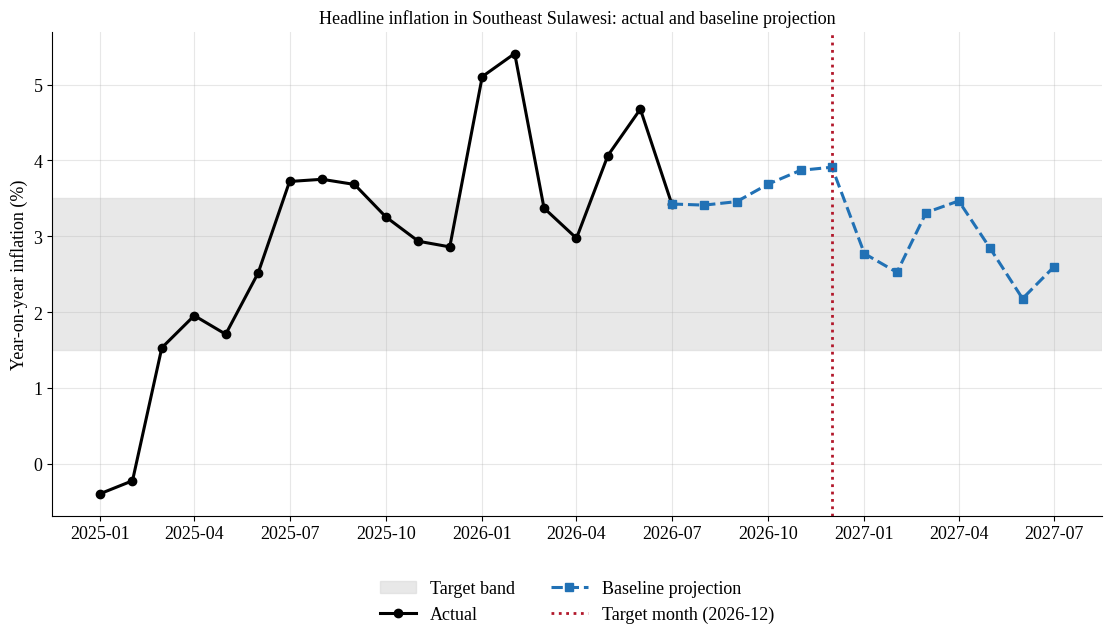

,Month,Baseline yoy inflation (%),Baseline general CPI
0,2026-08,3.41,114.08
1,2026-09,3.46,113.84
2,2026-10,3.69,113.43
3,2026-11,3.87,113.60
4,2026-12,3.91,113.90
5,2027-01,2.77,113.43
6,2027-02,2.53,113.90
7,2027-03,3.31,115.25
8,2027-04,3.47,116.00
9,2027-05,2.84,116.36


Data IHK terakhir adalah 2026-07 dengan inflasi tahunan 3,43 persen. Tanpa intervensi baru, proyeksi dasar
menghasilkan inflasi tahunan 3,91 persen pada 2026-12, di atas rentang sasaran 1,5 sampai 3,5 persen, dan berjarak
1,41 poin persen dari titik tengah. Indeks umum yang disusun kembali dari bobot tersirat berselisih paling besar
0,006 persen dari indeks resmi.



In [19]:
akhir = gen.index.max()
t0 = pd.Period(akhir, freq='M')
H = (pd.Period(TARGET_BULAN, freq='M') - t0).n
if H < 1 or H > 12:
    raise ValueError('TARGET_BULAN harus 1 sampai 12 bulan setelah ' + akhir)
bulan_depan = [str(t0 + h) for h in range(1, 13)]
dlog = np.log(sub).diff()
dlog['bulan_kal'] = [int(p[5:]) for p in dlog.index]
musiman = dlog.groupby('bulan_kal').mean().reindex(range(1, 13)).fillna(0.0)
lvl = sub.loc[akhir].copy()
proj = {}
for p in bulan_depan:
    lvl = lvl * np.exp(musiman.loc[int(p[5:]), sub.columns])
    proj[p] = lvl.copy()
proj = pd.DataFrame(proj).T
rekon = (sub * ws).sum(axis=1)
K_SKALA = gen.loc[akhir] / rekon.loc[akhir]
galat_rekon = ((rekon * K_SKALA) / gen - 1).abs().max() * 100
gen_dasar = (proj * ws).sum(axis=1) * K_SKALA
yoy_dasar = pd.Series({p: 100 * (gen_dasar[p] / gen[geser(p, -12)] - 1) for p in bulan_depan})
yoy_aktual = pd.Series({p: 100 * (gen[p] / gen[geser(p, -12)] - 1) for p in gen.index if geser(p, -12) in gen.index})
food_dasar = proj['011']
nonfood_dasar = (proj.drop(columns=kode_food) * ws.drop(kode_food)).sum(axis=1) / ws.drop(kode_food).sum()

fig, ax = plt.subplots(figsize=(11, 6.3), constrained_layout=True)
ax.axhspan(BATAS_BAWAH, BATAS_ATAS, color='#d9d9d9', alpha=0.6, label='Target band')
ya = yoy_aktual[yoy_aktual.index >= '2025-01']
ax.plot(pd.PeriodIndex(ya.index, freq='M').to_timestamp(), ya.values, color='black', lw=2.2, marker='o', label='Actual')
jalur = pd.concat([ya.iloc[-1:], yoy_dasar])
ax.plot(pd.PeriodIndex(jalur.index, freq='M').to_timestamp(), jalur.values, color='#2171b5', lw=2.2, ls='--', marker='s', label='Baseline projection')
ax.axvline(pd.Period(TARGET_BULAN, freq='M').to_timestamp(), color='#b2182b', ls=':', lw=2, label=f'Target month ({TARGET_BULAN})')
ax.set_ylabel('Year-on-year inflation (%)')
ax.set_title('Headline inflation in Southeast Sulawesi: actual and baseline projection')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)
simpan_gambar(fig, 'F11_baseline_projection', 'Actual and baseline headline inflation')

T17 = pd.DataFrame({'Month': yoy_dasar.index, 'Baseline yoy inflation (%)': yoy_dasar.values, 'Baseline general CPI': gen_dasar.values})
simpan_tabel(T17.round(3), 'T17_baseline_projection', 'Baseline projection of headline inflation')
display(T17.round(2))
posisi = 'di dalam' if BATAS_BAWAH <= yoy_dasar[TARGET_BULAN] <= BATAS_ATAS else ('di atas' if yoy_dasar[TARGET_BULAN] > BATAS_ATAS else 'di bawah')
tafsir('F11', f"Data IHK terakhir adalah {akhir} dengan inflasi tahunan {angka(yoy_aktual[akhir])} persen. Tanpa intervensi baru, proyeksi dasar menghasilkan inflasi tahunan {angka(yoy_dasar[TARGET_BULAN])} persen pada {TARGET_BULAN}, "
       f"{posisi} rentang sasaran {angka(BATAS_BAWAH, 1)} sampai {angka(BATAS_ATAS, 1)} persen, dan berjarak {angka(yoy_dasar[TARGET_BULAN] - SASARAN_TENGAH)} poin persen dari titik tengah. "
       f"Indeks umum yang disusun kembali dari bobot tersirat berselisih paling besar {angka(galat_rekon, 3)} persen dari indeks resmi.")

### 7.4 Inversi sasaran inflasi menjadi arahan harga

Sel berikut menghitung berapa persen harga tiap tuas harus berbeda dari lintasan dasar pada bulan sasaran agar inflasi tahunan tepat di titik tengah atau di batas rentang sasaran. Tuas ikan segar dan beras dianggap bergerak mengikuti subkelompok Makanan pada lintasan dasar. Hasil optimasi multituas lalu diterjemahkan menjadi batas pertumbuhan harga bulanan.

,Lever,CPI weight (%),Required change to reach midpoint (%),Required change to reach lower bound (%),Required change to reach upper bound (%)
0,Fresh fish,7.48,-17.79,-30.40,-5.18
1,Rice,5.09,-26.13,-44.65,-7.61
2,Other food,13.42,-9.91,-16.94,-2.89
3,Passenger transport services,3.04,-38.85,-66.39,-11.32
4,Electricity and household fuels,6.55,-22.09,-37.74,-6.44


,Lever,Baseline cumulative price change to target month (%),Adjustment to reach band edge (%),"Guided average monthly price change, band edge (%)",Adjustment to reach midpoint (%),"Guided average monthly price change, midpoint (%)"
0,Fresh fish,-3.57,-0.94,-0.91,-3.27,-1.38
1,Rice,-3.57,-0.64,-0.85,-2.26,-1.18
2,Other food,-3.57,-1.67,-1.06,-5.65,-1.87
3,Passenger transport services,1.28,-0.43,0.17,-1.54,-0.06
4,Electricity and household fuels,0.05,-0.76,-0.14,-2.66,-0.53


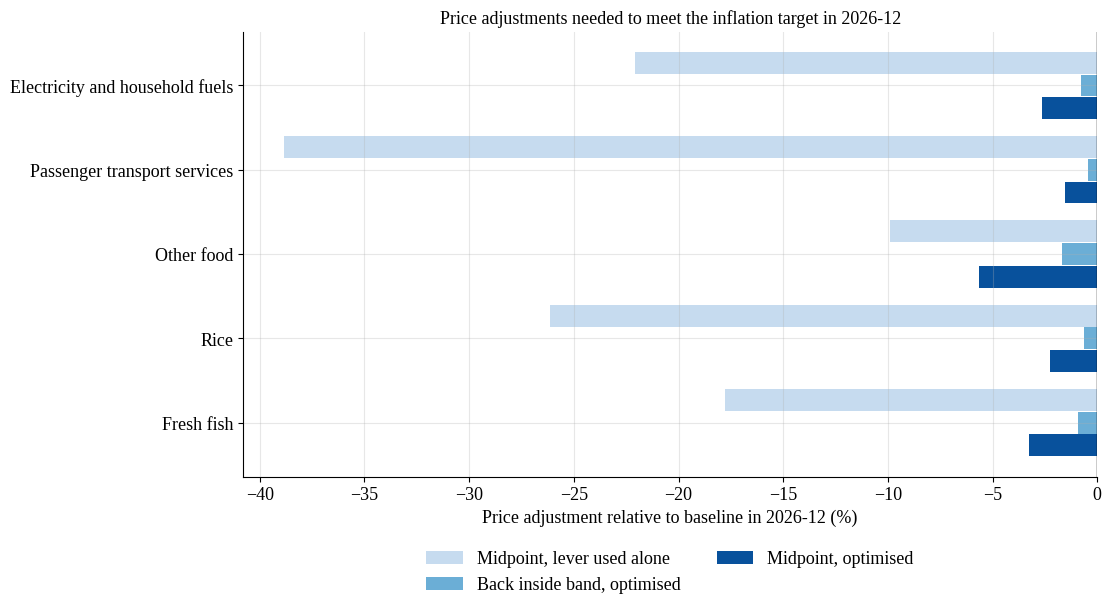

Agar inflasi tahunan 2026-12 tepat 2,5 persen, indeks umum perlu lebih rendah 1,358 persen dari lintasan dasar.
Bila hanya harga ikan segar yang dikendalikan, harganya perlu turun 17,8 persen terhadap lintasan dasar; bila hanya
makanan lain, harganya perlu turun 9,9 persen. Besaran penyesuaian ikan segar saja terlalu besar untuk dicapai satu
kebijakan, sehingga pengendalian perlu dibagi ke beberapa tuas. Untuk sekadar kembali ke dalam rentang sasaran
(batas atas 3,5 persen), indeks umum cukup lebih rendah 0,396 persen dari lintasan dasar. Pada alokasi optimal
untuk kembali ke dalam rentang, perubahan harga rata-rata per bulan yang diarahkan sampai bulan sasaran adalah:
ikan segar -0,911 persen (lintasan dasar -0,724 persen); beras -0,852 persen (lintasan dasar -0,724 persen);
makanan lain -1,058 persen (lintasan dasar -0,724 persen); jasa angkutan penumpang 0,167 persen (lintasan dasar
0,255 persen); listrik dan bahan bakar rumah tangga -0,142 persen (lintasan dasar 0,010 persen). Alok

In [20]:
T = TARGET_BULAN
dasar_T12 = gen[geser(T, -12)]
I_b = gen_dasar[T]
dI = {nama: dasar_T12 * (1 + v / 100) - I_b for nama, v in [('lower', BATAS_BAWAH), ('mid', SASARAN_TENGAH), ('upper', BATAS_ATAS)]}

def cari_kode(pola):
    x = w[(w['region_code'] == WILAYAH) & (w['level'] == 2) & w['item_name'].str.contains(pola, case=False, regex=True)]
    return x['coicop_code'].iloc[0] if len(x) else None

TUAS = {'Fresh fish': (W_FISH, '011'), 'Rice': (W_RICE, '011'), 'Other food': (w011 - W_FISH - W_RICE, '011')}
k_ang, k_lis = cari_kode('angkutan penumpang'), cari_kode('listrik')
if k_ang:
    TUAS['Passenger transport services'] = (float(ws[k_ang]), k_ang)
if k_lis:
    TUAS['Electricity and household fuels'] = (float(ws[k_lis]), k_lis)
nilai_tuas = {n_: K_SKALA * wt * proj.loc[T, kd] for n_, (wt, kd) in TUAS.items()}
T18 = pd.DataFrame([{'Lever': n_, 'CPI weight (%)': TUAS[n_][0] * 100,
                     'Required change to reach midpoint (%)': 100 * dI['mid'] / v_,
                     'Required change to reach lower bound (%)': 100 * dI['lower'] / v_,
                     'Required change to reach upper bound (%)': 100 * dI['upper'] / v_} for n_, v_ in nilai_tuas.items()])
simpan_tabel(T18.round(3), 'T18_single_lever_requirements', f'Price change required from each lever alone, {T}')
display(T18.round(2))

nama_t = list(TUAS)
v_arr = np.array([nilai_tuas[n_] for n_ in nama_t])
kappa = np.ones(len(nama_t))

def optimasi(target_dI):
    kendala = {'type': 'eq', 'fun': lambda x: np.sum(v_arr * (np.exp(x) - 1)) - target_dI}
    return optimize.minimize(lambda x: np.sum(kappa * x ** 2), x0=np.zeros(len(nama_t)), bounds=[BATAS_PENYESUAIAN] * len(nama_t),
                             constraints=[kendala], method='SLSQP')

yoy_b_T = yoy_dasar[T]
tepi = 'upper' if yoy_b_T > BATAS_ATAS else ('lower' if yoy_b_T < BATAS_BAWAH else None)
hasil_mid = optimasi(dI['mid'])
hasil_tepi = optimasi(dI[tepi]) if tepi else None
baris = []
for j, n_ in enumerate(nama_t):
    kd = TUAS[n_][1]
    g_dasar = proj.loc[T, kd] / sub.loc[akhir, kd] - 1
    r_ = {'Lever': n_, 'Baseline cumulative price change to target month (%)': g_dasar * 100}
    for lab_, hs_ in [('band edge', hasil_tepi), ('midpoint', hasil_mid)]:
        x_ = hs_.x[j] if hs_ is not None else 0.0
        g_arah = (1 + g_dasar) * np.exp(x_) - 1
        r_[f'Adjustment to reach {lab_} (%)'] = (np.exp(x_) - 1) * 100
        r_[f'Guided average monthly price change, {lab_} (%)'] = ((1 + g_arah) ** (1 / H) - 1) * 100
    baris.append(r_)
T19 = pd.DataFrame(baris)
simpan_tabel(T19.round(3), 'T19_optimised_price_guidance', f'Optimised price guidance for {T}')
display(T19.round(2))
yoy_cek = 100 * ((I_b + np.sum(v_arr * (np.exp(hasil_mid.x) - 1))) / dasar_T12 - 1)

fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
yy_ = np.arange(len(nama_t))
ax.barh(yy_ + 0.27, T18['Required change to reach midpoint (%)'], height=0.26, color='#c6dbef', label='Midpoint, lever used alone')
ax.barh(yy_, T19['Adjustment to reach band edge (%)'], height=0.26, color='#6baed6', label='Back inside band, optimised')
ax.barh(yy_ - 0.27, T19['Adjustment to reach midpoint (%)'], height=0.26, color='#08519c', label='Midpoint, optimised')
ax.set_yticks(yy_)
ax.set_yticklabels(nama_t)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel(f'Price adjustment relative to baseline in {T} (%)')
ax.set_title(f'Price adjustments needed to meet the inflation target in {T}')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=2, frameon=False)
simpan_gambar(fig, 'F12_price_guidance', 'Price adjustments needed to reach the inflation target')

arah = 'lebih rendah' if dI['mid'] < 0 else 'lebih tinggi'
ik = T18.set_index('Lever')
kal = [f"Agar inflasi tahunan {T} tepat {angka(SASARAN_TENGAH, 1)} persen, indeks umum perlu {arah} {angka(abs(dI['mid']) / I_b * 100, 3)} persen dari lintasan dasar."]
kal.append(f"Bila hanya harga ikan segar yang dikendalikan, harganya perlu {arah_persen(ik.loc['Fresh fish', 'Required change to reach midpoint (%)'])} terhadap lintasan dasar; "
           f"bila hanya makanan lain, harganya perlu {arah_persen(ik.loc['Other food', 'Required change to reach midpoint (%)'])}.")
if abs(ik.loc['Fresh fish', 'Required change to reach midpoint (%)']) > 15:
    kal.append("Besaran penyesuaian ikan segar saja terlalu besar untuk dicapai satu kebijakan, sehingga pengendalian perlu dibagi ke beberapa tuas.")
if tepi:
    kal.append(f"Untuk sekadar kembali ke dalam rentang sasaran ({'batas atas ' + angka(BATAS_ATAS, 1) if tepi == 'upper' else 'batas bawah ' + angka(BATAS_BAWAH, 1)} persen), indeks umum cukup "
               f"{arah} {angka(abs(dI[tepi]) / I_b * 100, 3)} persen dari lintasan dasar.")
    rinci = [f"{TUAS_ID.get(r['Lever'], r['Lever'])} {angka(r['Guided average monthly price change, band edge (%)'], 3)} persen "
             f"(lintasan dasar {angka(((1 + r['Baseline cumulative price change to target month (%)'] / 100) ** (1 / H) - 1) * 100, 3)} persen)" for _, r in T19.iterrows()]
    kal.append("Pada alokasi optimal untuk kembali ke dalam rentang, perubahan harga rata-rata per bulan yang diarahkan sampai bulan sasaran adalah: " + '; '.join(rinci) + ".")
else:
    kal.append("Lintasan dasar sudah berada di dalam rentang sasaran, sehingga penyesuaian hanya diperlukan bila sasaran yang dikejar adalah titik tengah.")
kal.append(f"Alokasi optimal untuk titik tengah menghasilkan inflasi {angka(yoy_cek)} persen (status optimasi: {'berhasil' if hasil_mid.success else 'tidak konvergen'}), "
           f"dengan pertumbuhan harga bulanan yang diarahkan antara {angka(T19['Guided average monthly price change, midpoint (%)'].min(), 3)} dan {angka(T19['Guided average monthly price change, midpoint (%)'].max(), 3)} persen.")
tafsir('F12', ' '.join(kal))

### 7.5 Simulasi sistem dinamis dan skenario kebijakan

Enam skenario dijalankan selama dua belas bulan ke depan. Besaran tuas pada skenario bersifat ilustratif dan dapat diubah; pencarian tuas terbaik dilakukan pada langkah 7.6.

,Scenario,f,s,a,g,YoY inflation 2026-12 (%),Inside target band,Fish producer price (baseline = 100),Fish consumer price (baseline = 100),Fishers terms of trade (baseline = 100),Poverty rate (%),Change in poor population (thousand)
0,S0 Baseline,0.00,0.00,0.00,0.000,3.911,No,100.000,100.000,100.000,10.020,0.000
1,S1 Logistics and cold chain,0.15,0.00,0.00,0.000,3.781,No,105.499,98.324,100.794,9.924,-2.770
2,S2 Market operation,0.00,0.05,0.00,0.000,3.602,No,93.880,96.022,99.329,9.792,-6.561
3,S3 Demand absorption,0.00,0.00,0.08,0.000,4.435,No,110.365,106.737,101.034,10.410,11.232
4,S4 Logistics plus absorption,0.15,0.00,0.08,0.000,4.328,No,116.325,105.361,101.810,10.330,8.926
5,S5 Combined with food supply management,0.15,0.00,0.08,0.002,4.136,No,116.319,105.357,101.919,10.187,4.806


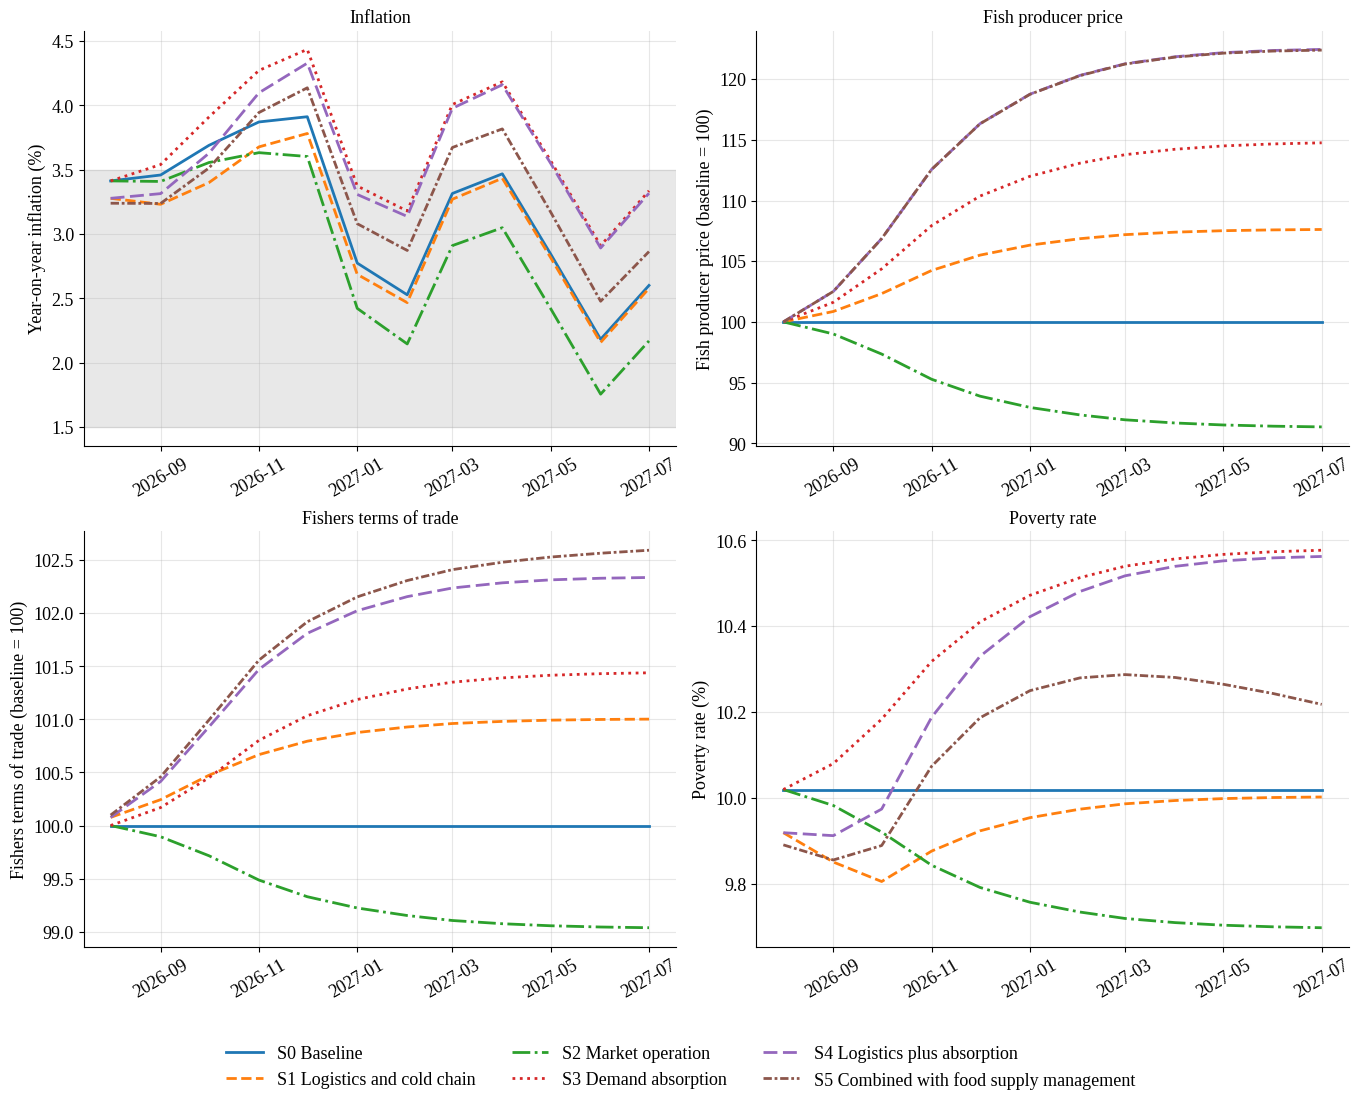

Pada skenario dasar, inflasi tahunan 2026-12 sebesar 3,91 persen dan persentase penduduk miskin tetap 10,02 persen.
Skenario S1 menghasilkan inflasi 3,78 persen (di luar rentang sasaran), nilai tukar nelayan 100,79 terhadap dasar
100, persentase penduduk miskin 9,924 persen, dan perubahan jumlah penduduk miskin -2,77 ribu orang. Skenario S2
menghasilkan inflasi 3,60 persen (di luar rentang sasaran), nilai tukar nelayan 99,33 terhadap dasar 100,
persentase penduduk miskin 9,792 persen, dan perubahan jumlah penduduk miskin -6,56 ribu orang. Skenario S3
menghasilkan inflasi 4,43 persen (di luar rentang sasaran), nilai tukar nelayan 101,03 terhadap dasar 100,
persentase penduduk miskin 10,410 persen, dan perubahan jumlah penduduk miskin 11,23 ribu orang. Skenario S4
menghasilkan inflasi 4,33 persen (di luar rentang sasaran), nilai tukar nelayan 101,81 terhadap dasar 100,
persentase penduduk miskin 10,330 persen, dan perubahan jumlah penduduk miskin 8,93 ribu orang. Skenario S5
menghasilkan

In [21]:
def simulasi(tuas, prm, bulan=bulan_depan):
    p_, K_ = 1.0, 1.0
    rekam = []
    for h, per_ in enumerate(bulan):
        ramp = min(1.0, (h + 1) / prm['ramp'])
        f_, a_, s_ = tuas['f'] * ramp, tuas['a'] * ramp, tuas['s'] * ramp
        r_ = np.exp(-tuas['g'] * (h + 1))
        c_ = (1 - prm['m0']) * p_ + prm['m0'] * (1 - f_)
        cpi_r = 1 + prm['w_fish'] * (c_ - 1) + prm['w_rest'] * (r_ - 1)
        ntn = p_ ** prm['theta'] / cpi_r ** prm['psi']
        d_ = c_ ** prm['eps_d'] * (1 + a_)
        q_ = K_ + s_
        food_r = (prm['w_fish'] * c_ + prm['w_rest'] * r_) / (prm['w_fish'] + prm['w_rest'])
        gk_r = prm['s_f'] * food_r + (1 - prm['s_f'])
        p0 = norm.cdf(prm['z0'] + np.log(gk_r) / prm['sigma']) * 100
        yoy_ = 100 * (gen_dasar[per_] * cpi_r / gen[geser(per_, -12)] - 1)
        rekam.append({'period': per_, 'yoy_inflation': yoy_, 'cpi_ratio': cpi_r, 'fish_producer_price': 100 * p_,
                      'fish_consumer_price': 100 * c_, 'fishers_terms_of_trade': 100 * ntn, 'fish_demand': 100 * d_,
                      'fish_supply': 100 * q_, 'fishing_capacity': 100 * K_, 'poverty_line_ratio': 100 * gk_r, 'poverty_rate': p0})
        K_ = K_ + (ntn ** prm['eps_s'] - K_) / prm['tau']
        p_ = p_ * np.exp(prm['phi'] * (d_ - q_))
    return pd.DataFrame(rekam)

SKENARIO = {
    'S0 Baseline': {'f': 0.0, 's': 0.0, 'a': 0.0, 'g': 0.0},
    'S1 Logistics and cold chain': {'f': 0.15, 's': 0.0, 'a': 0.0, 'g': 0.0},
    'S2 Market operation': {'f': 0.0, 's': 0.05, 'a': 0.0, 'g': 0.0},
    'S3 Demand absorption': {'f': 0.0, 's': 0.0, 'a': 0.08, 'g': 0.0},
    'S4 Logistics plus absorption': {'f': 0.15, 's': 0.0, 'a': 0.08, 'g': 0.0},
    'S5 Combined with food supply management': {'f': 0.15, 's': 0.0, 'a': 0.08, 'g': 0.002},
}
hasil_sk = {n_: simulasi(t_, PARAM) for n_, t_ in SKENARIO.items()}
for n_, df_ in hasil_sk.items():
    df_.to_csv(os.path.join(SUB['simulation'], 'scenario_' + re.sub(r'[^A-Za-z0-9]+', '_', n_).strip('_') + '.csv'), index=False)

baris = []
for n_, df_ in hasil_sk.items():
    r = df_.set_index('period').loc[T]
    baris.append({'Scenario': n_, 'f': SKENARIO[n_]['f'], 's': SKENARIO[n_]['s'], 'a': SKENARIO[n_]['a'], 'g': SKENARIO[n_]['g'],
                  f'YoY inflation {T} (%)': r['yoy_inflation'], 'Inside target band': 'Yes' if BATAS_BAWAH <= r['yoy_inflation'] <= BATAS_ATAS else 'No',
                  'Fish producer price (baseline = 100)': r['fish_producer_price'], 'Fish consumer price (baseline = 100)': r['fish_consumer_price'],
                  'Fishers terms of trade (baseline = 100)': r['fishers_terms_of_trade'], 'Poverty rate (%)': r['poverty_rate'],
                  'Change in poor population (thousand)': (r['poverty_rate'] - P0_0) / 100 * POP / 1000})
T20 = pd.DataFrame(baris)
simpan_tabel(T20.round(4), 'T20_scenario_results', f'System dynamics scenario results, {T}')
display(T20.round(3))

fig, axs = plt.subplots(2, 2, figsize=(13.5, 10), constrained_layout=True)
panel = [('yoy_inflation', 'Year-on-year inflation (%)'), ('fish_producer_price', 'Fish producer price (baseline = 100)'),
         ('fishers_terms_of_trade', 'Fishers terms of trade (baseline = 100)'), ('poverty_rate', 'Poverty rate (%)')]
gaya = ['-', '--', '-.', ':', (0, (5, 2)), (0, (3, 1, 1, 1))]
for ax, (kol, lab) in zip(axs.ravel(), panel):
    if kol == 'yoy_inflation':
        ax.axhspan(BATAS_BAWAH, BATAS_ATAS, color='#d9d9d9', alpha=0.6)
    for (n_, df_), ls in zip(hasil_sk.items(), gaya):
        ax.plot(pd.PeriodIndex(df_['period'], freq='M').to_timestamp(), df_[kol], ls=ls, lw=2, label=n_)
    ax.set_ylabel(lab)
    ax.tick_params(axis='x', rotation=30)
axs[0, 0].set_title('Inflation')
axs[0, 1].set_title('Fish producer price')
axs[1, 0].set_title('Fishers terms of trade')
axs[1, 1].set_title('Poverty rate')
hand, lab_ = axs[0, 0].get_legend_handles_labels()
fig.legend(hand, lab_, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)
simpan_gambar(fig, 'F13_scenarios', 'System dynamics scenarios')

s0 = T20.set_index('Scenario').loc['S0 Baseline']
kal = [f"Pada skenario dasar, inflasi tahunan {T} sebesar {angka(s0[f'YoY inflation {T} (%)'])} persen dan persentase penduduk miskin tetap {angka(s0['Poverty rate (%)'])} persen."]
for n_, r in T20.set_index('Scenario').iloc[1:].iterrows():
    kal.append(f"Skenario {n_[:2]} menghasilkan inflasi {angka(r[f'YoY inflation {T} (%)'])} persen ({'di dalam' if r['Inside target band'] == 'Yes' else 'di luar'} rentang sasaran), "
               f"nilai tukar nelayan {angka(r['Fishers terms of trade (baseline = 100)'])} terhadap dasar 100, persentase penduduk miskin {angka(r['Poverty rate (%)'], 3)} persen, "
               f"dan perubahan jumlah penduduk miskin {angka(r['Change in poor population (thousand)'], 2)} ribu orang.")
t20 = T20.set_index('Scenario')
s3, s4 = t20.loc['S3 Demand absorption'], t20.loc['S4 Logistics plus absorption']
if s3[f'YoY inflation {T} (%)'] > s0[f'YoY inflation {T} (%)'] and s3['Fishers terms of trade (baseline = 100)'] > 100:
    kal.append("Tambahan penyerapan permintaan tanpa tambahan pasokan menaikkan harga produsen dan nilai tukar nelayan, tetapi ikut menaikkan inflasi dan garis kemiskinan.")
    if s4[f'YoY inflation {T} (%)'] < s3[f'YoY inflation {T} (%)']:
        kal.append(f"Bila digabung dengan penurunan margin distribusi (S4), inflasi turun {angka(s3[f'YoY inflation {T} (%)'] - s4[f'YoY inflation {T} (%)'])} poin persen dibanding S3, sementara nilai tukar nelayan tetap di atas dasar.")
op = t20.loc['S2 Market operation']
if op['Fishers terms of trade (baseline = 100)'] < 100:
    kal.append("Operasi pasar menurunkan inflasi, tetapi menekan harga produsen dan nilai tukar nelayan; inilah pertukaran antara kepentingan konsumen dan produsen yang dijelaskan pada kerangka model.")
tafsir('F13', ' '.join(kal))

### 7.6 Pencarian kebijakan multitujuan

Kita mengambil sampel kombinasi tuas dengan Latin Hypercube Sampling (McKay dkk., 1979), menjalankan model untuk setiap kombinasi, lalu memilih solusi yang tidak didominasi (Deb dkk., 2002) untuk tiga tujuan pada bulan sasaran: jarak inflasi dari titik tengah sasaran (diminimumkan), persentase penduduk miskin (diminimumkan), dan nilai tukar nelayan (dimaksimumkan). Solusi kompromi adalah solusi Pareto yang paling dekat dengan titik ideal setelah ketiga tujuan dinormalisasi.

,f,s,a,g,Distance to target midpoint (pp),YoY inflation 2026-12 (%),Poverty rate (%),Fishers terms of trade (baseline = 100),Normalised distance to ideal
0,0.2984,0.0134,0.0199,0.0038,0.8599,3.3599,9.6150,101.8865,0.7087
1,0.2966,0.0977,0.0976,0.0037,0.8516,3.3516,9.6089,101.8336,0.7166
2,0.2945,0.0265,0.0041,0.0034,0.7059,3.2059,9.5030,101.4786,0.7379
3,0.2801,0.0405,0.0137,0.0040,0.6358,3.1358,9.4521,101.3833,0.7393
4,0.2923,0.0584,0.0818,0.0040,0.9762,3.4762,9.6999,102.0962,0.7399
5,0.2943,0.0792,0.0880,0.0035,0.9210,3.4210,9.6595,101.9121,0.7414
6,0.2837,0.0444,0.0636,0.0039,0.9537,3.4537,9.6835,101.9886,0.7464
7,0.2867,0.0428,0.0315,0.0034,0.7939,3.2939,9.5669,101.5896,0.7478
8,0.2857,0.0905,0.0744,0.0033,0.7839,3.2839,9.5597,101.5479,0.7542
9,0.2772,0.0553,0.0212,0.0039,0.6034,3.1034,9.4287,101.2784,0.7611


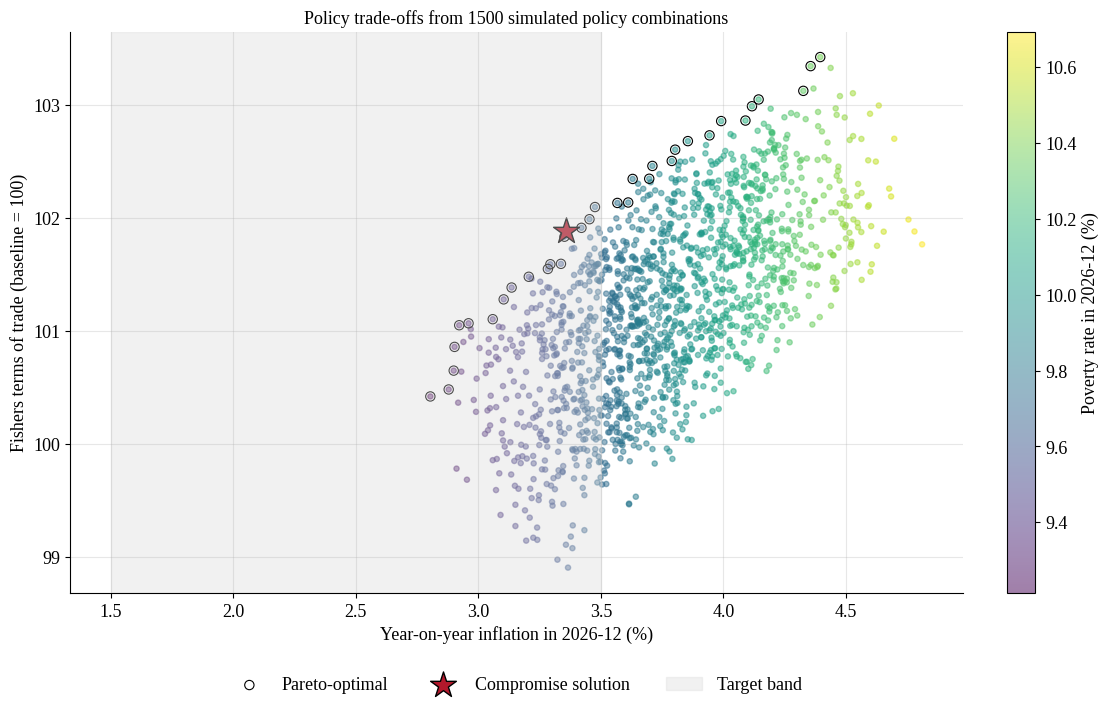

Dari 1500 kombinasi tuas, 34 kombinasi tidak didominasi. Solusi kompromi memakai penurunan margin distribusi 29,8
persen, operasi pasar 1,3 persen dari pasokan, tambahan penyerapan permintaan 2,0 persen, dan moderasi harga pangan
lain 0,380 persen per bulan. Kombinasi ini menghasilkan inflasi 3,36 persen pada 2026-12, persentase penduduk
miskin 9,615 persen, dan nilai tukar nelayan 101,89 terhadap dasar 100.



In [22]:
def lhs(n, d, rng):
    batas = np.linspace(0, 1, n + 1)
    u = rng.random((n, d)) * (batas[1:] - batas[:-1])[:, None] + batas[:-1][:, None]
    for j in range(d):
        u[:, j] = rng.permutation(u[:, j])
    return u

kunci_tuas = list(RENTANG_TUAS)
N_SAMPEL = 1500
u = lhs(N_SAMPEL, len(kunci_tuas), RNG)
sampel = np.column_stack([RENTANG_TUAS[k_][0] + u[:, j] * (RENTANG_TUAS[k_][1] - RENTANG_TUAS[k_][0]) for j, k_ in enumerate(kunci_tuas)])
bulan_T = [p for p in bulan_depan if p <= T]
F_obj = []
for row in sampel:
    df_ = simulasi(dict(zip(kunci_tuas, row)), PARAM, bulan_T)
    r = df_.iloc[-1]
    F_obj.append([abs(r['yoy_inflation'] - SASARAN_TENGAH), r['poverty_rate'], -r['fishers_terms_of_trade'], r['yoy_inflation'], r['fishers_terms_of_trade']])
F_obj = np.array(F_obj)

def tak_didominasi(F):
    n = len(F)
    kalah = np.zeros(n, dtype=bool)
    for i in range(n):
        if kalah[i]:
            continue
        dom = np.all(F <= F[i], axis=1) & np.any(F < F[i], axis=1)
        if dom.any():
            kalah[i] = True
    return ~kalah

pareto = tak_didominasi(F_obj[:, :3])
Fp = F_obj[pareto, :3]
norm_ = (Fp - Fp.min(axis=0)) / np.where(Fp.max(axis=0) - Fp.min(axis=0) > 0, Fp.max(axis=0) - Fp.min(axis=0), 1)
jarak = np.sqrt((norm_ ** 2).sum(axis=1))
idx_p = np.where(pareto)[0]
kompromi = idx_p[np.argmin(jarak)]
TUAS_KOMPROMI = dict(zip(kunci_tuas, sampel[kompromi]))

T21 = pd.DataFrame(sampel[idx_p], columns=kunci_tuas)
T21['Distance to target midpoint (pp)'] = F_obj[idx_p, 0]
T21[f'YoY inflation {T} (%)'] = F_obj[idx_p, 3]
T21['Poverty rate (%)'] = F_obj[idx_p, 1]
T21['Fishers terms of trade (baseline = 100)'] = F_obj[idx_p, 4]
T21['Normalised distance to ideal'] = jarak
T21 = T21.sort_values('Normalised distance to ideal').reset_index(drop=True)
simpan_tabel(T21.round(4), 'T21_pareto_solutions', 'Pareto-optimal policy combinations')
display(T21.head(10).round(4))

fig, ax = plt.subplots(figsize=(11, 7), constrained_layout=True)
sc = ax.scatter(F_obj[:, 3], F_obj[:, 4], c=F_obj[:, 1], cmap='viridis', s=14, alpha=0.5)
ax.scatter(F_obj[pareto, 3], F_obj[pareto, 4], facecolors='none', edgecolors='black', s=45, lw=0.8, label='Pareto-optimal')
ax.scatter(F_obj[kompromi, 3], F_obj[kompromi, 4], marker='*', s=380, color='#b2182b', edgecolors='black', label='Compromise solution')
ax.axvspan(BATAS_BAWAH, BATAS_ATAS, color='#d9d9d9', alpha=0.35, label='Target band')
cb = fig.colorbar(sc, ax=ax)
cb.set_label(f'Poverty rate in {T} (%)')
ax.set_xlabel(f'Year-on-year inflation in {T} (%)')
ax.set_ylabel('Fishers terms of trade (baseline = 100)')
ax.set_title(f'Policy trade-offs from {N_SAMPEL} simulated policy combinations')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)
simpan_gambar(fig, 'F14_pareto_front', 'Policy trade-offs and Pareto-optimal combinations')

rk = T21.iloc[0]
tafsir('F14', f"Dari {N_SAMPEL} kombinasi tuas, {int(pareto.sum())} kombinasi tidak didominasi. Solusi kompromi memakai penurunan margin distribusi {angka(rk['f'] * 100, 1)} persen, "
       f"operasi pasar {angka(rk['s'] * 100, 1)} persen dari pasokan, tambahan penyerapan permintaan {angka(rk['a'] * 100, 1)} persen, dan moderasi harga pangan lain {angka(rk['g'] * 100, 3)} persen per bulan. "
       f"Kombinasi ini menghasilkan inflasi {angka(rk[f'YoY inflation {T} (%)'])} persen pada {T}, persentase penduduk miskin {angka(rk['Poverty rate (%)'], 3)} persen, "
       f"dan nilai tukar nelayan {angka(rk['Fishers terms of trade (baseline = 100)'])} terhadap dasar 100.")

### 7.7 Uji sensitivitas

Parameter yang berupa asumsi dan parameter hasil estimasi diacak dalam rentang ujinya (500 kali) dengan tuas tetap pada solusi kompromi. Kita melaporkan sebaran hasil dan peluang inflasi berada di dalam rentang sasaran.

,Outcome,P5,P25,Median,P75,P95
0,YoY inflation 2026-12 (%),3.058,3.237,3.375,3.488,3.561
1,Fishers terms of trade (baseline = 100),100.907,101.322,101.818,102.305,103.281
2,Poverty rate (%),9.389,9.530,9.621,9.709,9.765


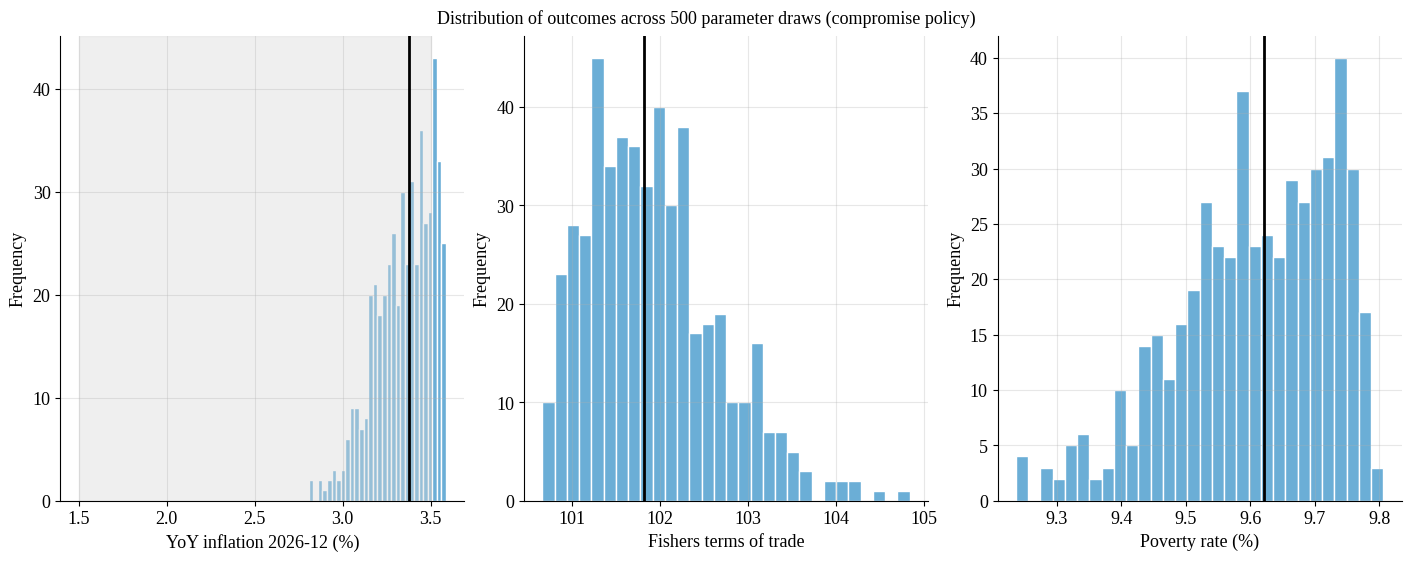

Pada 500 kali pengacakan parameter, median inflasi 2026-12 sebesar 3,37 persen dengan rentang persentil 5 sampai 95
antara 3,06 dan 3,56 persen. Peluang inflasi berada di dalam rentang sasaran sebesar 78,2 persen. Nilai tukar
nelayan berkisar 100,91 sampai 103,28, dan persentase penduduk miskin berkisar 9,389 sampai 9,765 persen.



In [23]:
N_MC = 500
hasil_mc = []
for i in range(N_MC):
    prm = dict(PARAM)
    prm['eps_d'] = RNG.uniform(-1.2, -0.4)
    prm['eps_s'] = RNG.uniform(0.1, 0.6)
    prm['tau'] = RNG.uniform(3, 12)
    prm['phi'] = RNG.uniform(0.3, 1.0)
    prm['m0'] = RNG.uniform(0.25, 0.45)
    prm['theta'] = float(np.clip(RNG.normal(THETA, THETA_SE if THETA == THETA_EST else 0.2), 0.05, 1.5))
    prm['psi'] = float(np.clip(RNG.normal(PSI, PSI_SE if PSI == PSI_EST else 0.2), 0.2, 1.5))
    gini_ = float(np.clip(RNG.normal(GINI, 0.02), 0.2, 0.6))
    prm['sigma'] = np.sqrt(2) * norm.ppf((1 + gini_) / 2)
    r = simulasi(TUAS_KOMPROMI, prm, bulan_T).iloc[-1]
    hasil_mc.append({'yoy': r['yoy_inflation'], 'ntn': r['fishers_terms_of_trade'], 'p0': r['poverty_rate']})
mc = pd.DataFrame(hasil_mc)
T22 = mc.quantile([0.05, 0.25, 0.5, 0.75, 0.95]).T
T22.columns = ['P5', 'P25', 'Median', 'P75', 'P95']
T22.index = [f'YoY inflation {T} (%)', 'Fishers terms of trade (baseline = 100)', 'Poverty rate (%)']
T22 = T22.reset_index().rename(columns={'index': 'Outcome'})
peluang = ((mc['yoy'] >= BATAS_BAWAH) & (mc['yoy'] <= BATAS_ATAS)).mean() * 100
simpan_tabel(T22.round(4), 'T22_sensitivity', 'Sensitivity of outcomes under the compromise policy')
display(T22.round(3))

fig, axs = plt.subplots(1, 3, figsize=(14, 5.5), constrained_layout=True)
for ax, kol, lab in zip(axs, ['yoy', 'ntn', 'p0'], [f'YoY inflation {T} (%)', 'Fishers terms of trade', 'Poverty rate (%)']):
    ax.hist(mc[kol], bins=30, color='#6baed6', edgecolor='white')
    ax.axvline(mc[kol].median(), color='black', lw=2)
    ax.set_xlabel(lab)
    ax.set_ylabel('Frequency')
axs[0].axvspan(BATAS_BAWAH, BATAS_ATAS, color='#d9d9d9', alpha=0.4)
fig.suptitle(f'Distribution of outcomes across {N_MC} parameter draws (compromise policy)')
simpan_gambar(fig, 'F15_sensitivity', 'Sensitivity of outcomes to model parameters')
tafsir('F15', f"Pada {N_MC} kali pengacakan parameter, median inflasi {T} sebesar {angka(mc['yoy'].median())} persen dengan rentang persentil 5 sampai 95 antara {angka(mc['yoy'].quantile(0.05))} dan {angka(mc['yoy'].quantile(0.95))} persen. "
       f"Peluang inflasi berada di dalam rentang sasaran sebesar {angka(peluang, 1)} persen. Nilai tukar nelayan berkisar {angka(mc['ntn'].quantile(0.05))} sampai {angka(mc['ntn'].quantile(0.95))}, "
       f"dan persentase penduduk miskin berkisar {angka(mc['p0'].quantile(0.05), 3)} sampai {angka(mc['p0'].quantile(0.95), 3)} persen.")

## Langkah 8. Menyimpan dan memaketkan keluaran

Semua tabel disatukan ke satu berkas Excel, interpretasi otomatis ditulis ke satu berkas Markdown, dan folder keluaran dipaketkan menjadi `output_forkestra2026.zip`.

In [24]:
with pd.ExcelWriter(os.path.join(OUT_DIR, 'tables_forkestra2026.xlsx')) as xw:
    pd.DataFrame([{'Sheet': k_, 'Title': v_[0]} for k_, v_ in TABEL.items()]).to_excel(xw, sheet_name='INDEX', index=False)
    for k_, (judul, df_) in TABEL.items():
        df_.to_excel(xw, sheet_name=k_[:31], index=False)

with open(os.path.join(SUB['interpretations'], 'interpretasi_otomatis.md'), 'w', encoding='utf-8') as f:
    f.write('# Interpretasi otomatis\n\n')
    for k_, daftar in TAFSIR.items():
        f.write(f'## {k_}\n\n')
        for t_ in daftar:
            f.write(t_ + '\n\n')

manifest = pd.DataFrame([{'Type': 'Table', 'Code': k_, 'Title': v_[0], 'File': f'tables/{k_}.csv'} for k_, v_ in TABEL.items()] +
                        [{'Type': 'Figure', 'Code': k_, 'Title': v_[0], 'File': f'figures/{k_}.png'} for k_, v_ in GAMBAR.items()])
manifest.to_csv(os.path.join(OUT_DIR, 'manifest.csv'), index=False)
with open(os.path.join(OUT_DIR, 'run_settings.json'), 'w', encoding='utf-8') as f:
    json.dump({'target_month': TARGET_BULAN, 'target_midpoint': SASARAN_TENGAH, 'deviation': DEVIASI, 'region': WILAYAH,
               'parameters': {k_: float(v_) for k_, v_ in PARAM.items()}, 'compromise_levers': {k_: float(v_) for k_, v_ in TUAS_KOMPROMI.items()},
               'font': FONT_UTAMA}, f, indent=2)

zip_path = shutil.make_archive(os.path.join(BASE_DIR, 'output_forkestra2026'), 'zip', OUT_DIR)
print('Tabel:', len(TABEL), '| Gambar:', len(GAMBAR), '| Kelompok interpretasi:', len(TAFSIR))
print('Berkas ZIP:', zip_path)
if DI_COLAB:
    from google.colab import files
    files.download(zip_path)
else:
    from IPython.display import FileLink, display
    display(FileLink(os.path.relpath(zip_path)))

Tabel: 22 | Gambar: 15 | Kelompok interpretasi: 19
Berkas ZIP: /content/output_forkestra2026.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Daftar pustaka

Badan Pusat Statistik. (2020). *Diagram timbang indeks harga konsumen hasil Survei Biaya Hidup 2018* (Buku 4). Badan Pusat Statistik. https://www.bps.go.id

Badan Pusat Statistik Provinsi Sulawesi Tenggara. (2026, 5 Agustus). *Persentase penduduk miskin Maret 2026 turun menjadi 10,02 persen* [Berita Resmi Statistik]. https://sultra.bps.go.id/id/pressrelease

Bank Indonesia. (2026). *Target inflasi*. https://www.bi.go.id/id/statistik/indikator/target-inflasi.aspx

Deb, K., Pratap, A., Agarwal, S., & Meyarivan, T. (2002). A fast and elitist multiobjective genetic algorithm: NSGA-II. *IEEE Transactions on Evolutionary Computation, 6*(2), 182-197. https://doi.org/10.1109/4235.996017

Dey, M. M., Garcia, Y. T., Kumar, P., Piumsombun, S., Haque, M. S., Li, L., Radam, A., Senaratne, A., Khiem, N. T., & Koeshendrajana, S. (2008). Demand for fish in Asia: A cross-country analysis. *Australian Journal of Agricultural and Resource Economics, 52*(3), 321-338. https://doi.org/10.1111/j.1467-8489.2008.00418.x

Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and practice* (3rd ed.). OTexts. https://otexts.com/fpp3/

International Monetary Fund, International Labour Organization, Eurostat, United Nations Economic Commission for Europe, Organisation for Economic Co-operation and Development, & World Bank. (2020). *Consumer price index manual: Concepts and methods*. International Monetary Fund. https://www.elibrary.imf.org/display/book/9781484354841/9781484354841.xml

Kementerian Keuangan Republik Indonesia. (2024). *Peraturan Menteri Keuangan Nomor 31 Tahun 2024 tentang Sasaran Inflasi Tahun 2025, Tahun 2026, dan Tahun 2027*. https://jdih.kemenkeu.go.id/dok/pmk-31-tahun-2024/summary

Kementerian Kelautan dan Perikanan. (2026). *Portal data kelautan dan perikanan* [Data set]. https://portaldata.kkp.go.id

Lawson, C. L., & Hanson, R. J. (1995). *Solving least squares problems*. Society for Industrial and Applied Mathematics. https://doi.org/10.1137/1.9781611971217

López, J. H., & Servén, L. (2006). *A normal relationship? Poverty, growth, and inequality* (Policy Research Working Paper No. 3814). World Bank. https://doi.org/10.1596/1813-9450-3814

McKay, M. D., Beckman, R. J., & Conover, W. J. (1979). A comparison of three methods for selecting values of input variables in the analysis of output from a computer code. *Technometrics, 21*(2), 239-245. https://doi.org/10.2307/1268522

Sterman, J. D. (2000). *Business dynamics: Systems thinking and modeling for a complex world*. Irwin/McGraw-Hill.

Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S. J., Brett, M., Wilson, J., Millman, K. J., Mayorov, N., Nelson, A. R. J., Jones, E., Kern, R., Larson, E., ... SciPy 1.0 Contributors. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods, 17*(3), 261-272. https://doi.org/10.1038/s41592-019-0686-2